# 13 — Stance Time Series & Model Disagreement

1. Net hawk score over time — one panel per bank, one line per model
2. Chunk-level agreement rate and disagreement categories
3. Temporal disagreement — meeting-level score gap
4. Turning point agreement
5. Delta/shift analysis — meeting-to-meeting changes
6. Semantic representation space (embeddings)
7. Disagreement by linguistic features (logistic regression)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

ROOT    = Path('..').resolve()
OUT_DIR = ROOT / 'output' / 'stance'

BANKS = ['BoE', 'ECB', 'Fed']

STANCE_SCORE = {
    'dovish':        -1.0,
    'mostly dovish': -0.5,
    'neutral':        0.0,
    'mostly hawkish': 0.5,
    'hawkish':        1.0,
}
CONFIDENCE_SCORE = {'low': 1, 'medium': 2, 'high': 3}
DIRECTION_MAP = {
    'dovish': 'dovish', 'mostly dovish': 'dovish',
    'neutral': 'neutral',
    'mostly hawkish': 'hawkish', 'hawkish': 'hawkish',
}
DIRECTIONAL = ['dovish', 'mostly dovish', 'mostly hawkish', 'hawkish']

# Add models here as they finish
MODELS = {
    'llama33':         {'label': 'Llama 3.3 70B',   'color': '#4C72B0', 'ls': '-'},
    'deepseekv3':      {'label': 'DeepSeek V3',      'color': '#DD8452', 'ls': '-'},
    'qwen25_72b':      {'label': 'Qwen 2.5 72B',     'color': '#55A868', 'ls': '-'},
    'mistrallarge_or': {'label': 'Mistral Large',    'color': '#C44E52', 'ls': '-'},
}

## 1. Load & aggregate all models

In [2]:
def load_predictions(model_key):
    path = OUT_DIR / f'chunk_predictions_{model_key}.csv'
    if not path.exists():
        print(f'  {model_key}: not found, skipping')
        return None
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'].astype(str), format='%Y%m%d')
    valid = df['label'].isin(STANCE_SCORE) & df['confidence'].isin(CONFIDENCE_SCORE)
    n_err = (~valid).sum()
    if n_err:
        print(f'  {model_key}: dropping {n_err} parse_error rows ({n_err/len(df):.1%})')
    df = df[valid].copy()
    df['score'] = df['label'].map(STANCE_SCORE)
    df['conf_numeric'] = df['confidence'].map(CONFIDENCE_SCORE)
    print(f'  {model_key}: {len(df):,} chunks, {df["doc_id"].nunique()} meetings')
    return df


def aggregate_meetings(df):
    rows = []
    for (bank, doc_id, date), grp in df.groupby(['bank', 'doc_id', 'date']):
        n  = len(grp)
        H  = (grp['label'] == 'hawkish').sum()
        MH = (grp['label'] == 'mostly hawkish').sum()
        D  = (grp['label'] == 'dovish').sum()
        MD = (grp['label'] == 'mostly dovish').sum()
        hawk_mass = H + 0.5 * MH
        dove_mass = D + 0.5 * MD
        wi = grp['n_sentences'].fillna(1)
        rows.append({
            'bank':          bank,
            'doc_id':        doc_id,
            'date':          date,
            'n_chunks':      n,
            'net_hawk':      (hawk_mass - dove_mass) / n,
            'logit':         np.log((hawk_mass + 0.5) / (dove_mass + 0.5)),
            'wtd_net_hawk':  (wi * grp['score']).sum() / wi.sum(),
            'mean_conf':     grp['conf_numeric'].mean(),
            'pct_high_conf': (grp['confidence'] == 'high').mean(),
        })
    return pd.DataFrame(rows).sort_values(['bank', 'date'])


print('Loading models:')
all_chunks   = {}
all_meetings = {}
for key in MODELS:
    df = load_predictions(key)
    if df is not None:
        all_chunks[key]   = df
        all_meetings[key] = aggregate_meetings(df)

loaded = list(all_chunks.keys())
print(f'\nLoaded: {loaded}')
if len(loaded) >= 2:
    key_a, key_b   = loaded[0], loaded[1]
    label_a, label_b = MODELS[key_a]['label'], MODELS[key_b]['label']

Loading models:
  llama33: 5,004 chunks, 204 meetings
  deepseekv3: dropping 6 parse_error rows (0.1%)
  deepseekv3: 4,998 chunks, 204 meetings
  qwen25_72b: dropping 1 parse_error rows (0.0%)
  qwen25_72b: 5,003 chunks, 204 meetings
  mistrallarge_or: 5,004 chunks, 204 meetings

Loaded: ['llama33', 'deepseekv3', 'qwen25_72b', 'mistrallarge_or']


## 2. Net hawk score over time

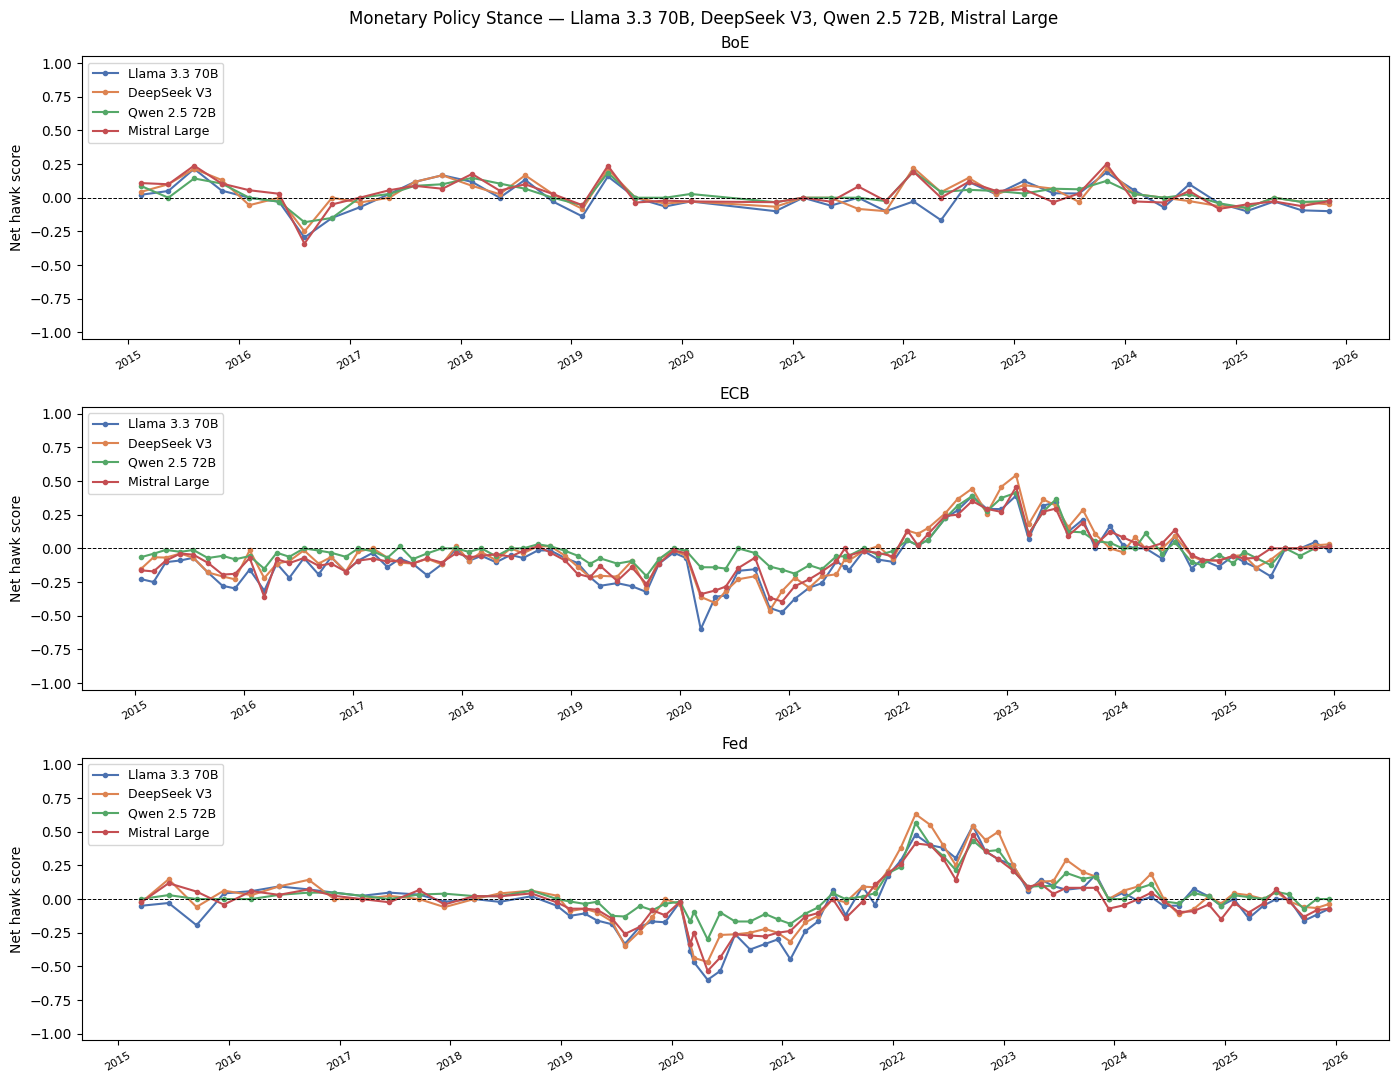

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
for ax, bank in zip(axes, BANKS):
    for key, meta in MODELS.items():
        if key not in all_meetings:
            continue
        bdf = all_meetings[key][all_meetings[key]['bank'] == bank].sort_values('date')
        ax.plot(bdf['date'], bdf['net_hawk'], color=meta['color'], linestyle=meta['ls'],
                linewidth=1.5, marker='o', markersize=3, label=meta['label'])
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(bank, fontsize=11)
    ax.set_ylabel('Net hawk score')
    ax.set_ylim(-1.05, 1.05)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.legend(fontsize=9, loc='upper left')

model_labels = ', '.join(MODELS[k]['label'] for k in all_meetings)
out_name = '_'.join(all_meetings.keys())
plt.suptitle(f'Monetary Policy Stance — {model_labels}', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / f'timeseries_net_hawk_{out_name}.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Multi-model agreement — Cohen's κ & stanced analysis

=== Hierarchical κ decomposition ===
                          pair  n_both_stanced  kappa_stanced  kappa_direction
  Llama 3.3 70B vs DeepSeek V3             897          0.594            0.912
 Llama 3.3 70B vs Qwen 2.5 72B             750          0.560            0.936
Llama 3.3 70B vs Mistral Large            1122          0.691            0.878
   DeepSeek V3 vs Qwen 2.5 72B             616          0.600            0.980
  DeepSeek V3 vs Mistral Large             860          0.627            0.908
 Qwen 2.5 72B vs Mistral Large             701          0.574            0.946


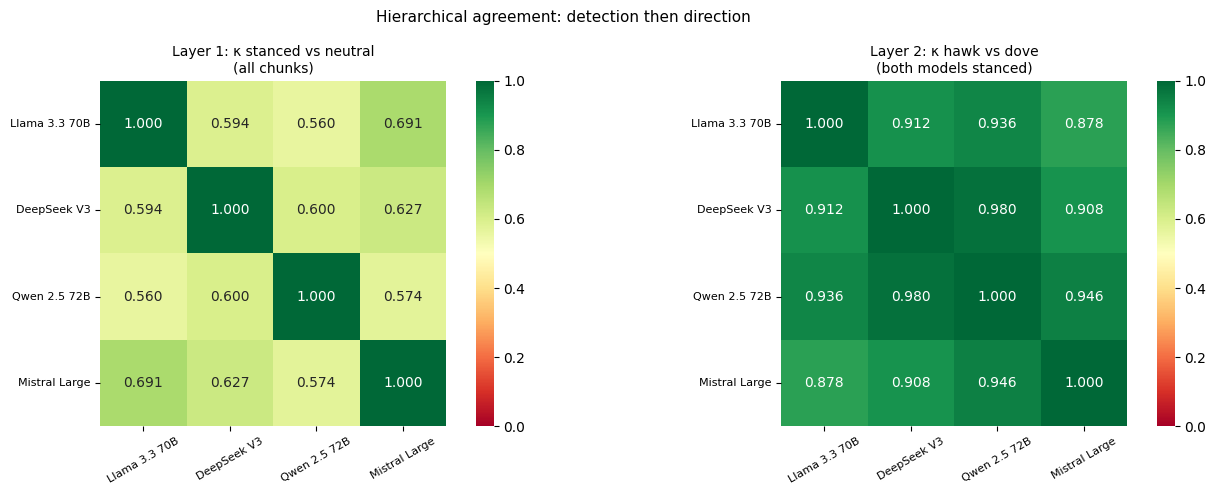

In [8]:
# ── Hierarchical κ: stanced/neutral then hawk/dove direction ──────────────────
HAWK_LABELS = {'mostly hawkish', 'hawkish'}
DOVE_LABELS = {'dovish', 'mostly dovish'}

for key in loaded:
    chunks_wide[f'direction_{key}'] = chunks_wide[f'label_{key}'].map(
        lambda l: 'hawk' if l in HAWK_LABELS else ('dove' if l in DOVE_LABELS else None)
    )

rows = []
for a, b in pairs:
    # Layer 1: stanced vs neutral (all chunks)
    k_stanced = cohen_kappa_score(
        chunks_wide[f'stanced_{a}'].astype(int),
        chunks_wide[f'stanced_{b}'].astype(int),
    )

    # Layer 2: hawk vs dove — only where BOTH models called it stanced
    both_stanced = chunks_wide[
        chunks_wide[f'stanced_{a}'] & chunks_wide[f'stanced_{b}']
    ]
    k_direction = cohen_kappa_score(
        both_stanced[f'direction_{a}'],
        both_stanced[f'direction_{b}'],
    )

    rows.append({
        'pair':          f'{MODELS[a]["label"]} vs {MODELS[b]["label"]}',
        'n_both_stanced': len(both_stanced),
        'kappa_stanced':  k_stanced,
        'kappa_direction': k_direction,
    })

kappa_hier = pd.DataFrame(rows)
print("=== Hierarchical κ decomposition ===")
print(kappa_hier.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
    (axes[0], 'kappa_stanced',   "Layer 1: κ stanced vs neutral\n(all chunks)"),
    (axes[1], 'kappa_direction', "Layer 2: κ hawk vs dove\n(both models stanced)"),
]:
    mat = pd.DataFrame(1.0, index=loaded, columns=loaded)
    for (a, b), row in zip(pairs, rows):
        mat.loc[a, b] = row[col]
        mat.loc[b, a] = row[col]
    mat.index   = [MODELS[k]['label'] for k in loaded]
    mat.columns = [MODELS[k]['label'] for k in loaded]
    sns.heatmap(mat.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, square=True)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle("Hierarchical agreement: detection then direction", fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'agreement_kappa_hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()


All neutral:       3,145 (62.9%)
Contested (≥1):    1,852 (37.1%)
Majority stanced:  933 (18.7%)


c:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\.venv\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)
c:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\.venv\Lib\site-packages\sklearn\metrics\_classification.py:991: Runtim

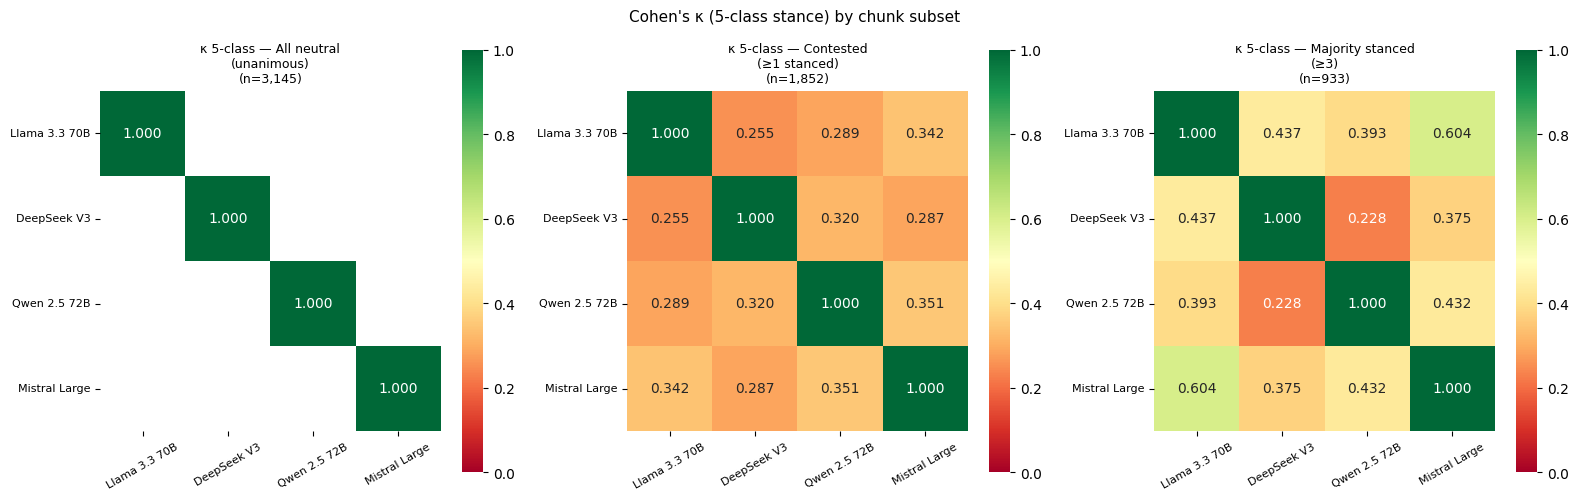

In [7]:
# ── κ by stance-consensus subset ──────────────────────────────────────────────
all_neutral      = chunks_wide[chunks_wide['n_stanced'] == 0]
contested        = chunks_wide[chunks_wide['n_stanced'] >= 1]
majority_stanced = chunks_wide[chunks_wide['n_stanced'] >= 3]

subsets = [
    ('All neutral\n(unanimous)',    all_neutral),
    ('Contested\n(≥1 stanced)',     contested),
    ('Majority stanced\n(≥3)',      majority_stanced),
]

print(f"All neutral:       {len(all_neutral):,} ({len(all_neutral)/len(chunks_wide):.1%})")
print(f"Contested (≥1):    {len(contested):,} ({len(contested)/len(chunks_wide):.1%})")
print(f"Majority stanced:  {len(majority_stanced):,} ({len(majority_stanced)/len(chunks_wide):.1%})")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, df) in zip(axes, subsets):
    mat = pd.DataFrame(1.0, index=loaded, columns=loaded)
    for a, b in pairs:
        k = cohen_kappa_score(df[f'label_{a}'], df[f'label_{b}'])
        mat.loc[a, b] = k
        mat.loc[b, a] = k
    mat.index   = [MODELS[k]['label'] for k in loaded]
    mat.columns = [MODELS[k]['label'] for k in loaded]
    sns.heatmap(mat.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, square=True)
    ax.set_title(f"κ 5-class — {title}\n(n={len(df):,})", fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle("Cohen's κ (5-class stance) by chunk subset", fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'agreement_kappa_subsets.png', dpi=150, bbox_inches='tight')
plt.show()


Wide frame: 4,997 chunks, 4 models

Stance consensus (all 4 models must agree):
  All stanced:  11.5%
  All neutral:  62.9%
  Split:        25.5%

=== All-pairs agreement & Cohen's κ ===
                            pair  agree_5class  kappa_5class  agree_stanced  kappa_stanced
  Llama 3.3 70B  vs  DeepSeek V3         0.777         0.488          0.843          0.594
 Llama 3.3 70B  vs  Qwen 2.5 72B         0.791         0.478          0.839          0.560
Llama 3.3 70B  vs  Mistral Large         0.816         0.605          0.873          0.691
   DeepSeek V3  vs  Qwen 2.5 72B         0.826         0.465          0.880          0.600
  DeepSeek V3  vs  Mistral Large         0.794         0.498          0.863          0.627
 Qwen 2.5 72B  vs  Mistral Large         0.823         0.521          0.854          0.574


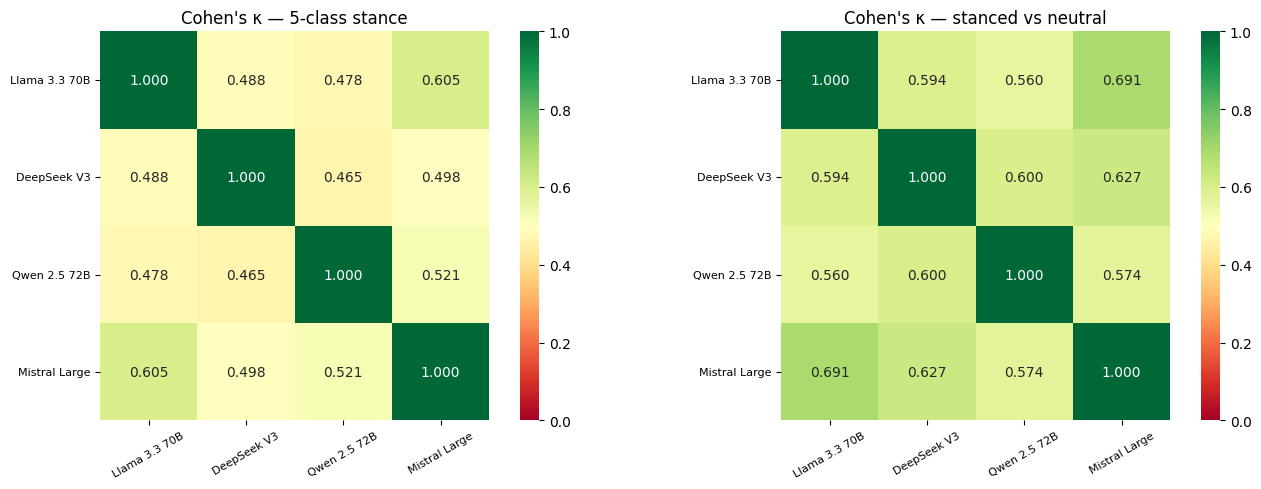

In [6]:
from itertools import combinations
from sklearn.metrics import cohen_kappa_score

# ── Wide frame: one row per chunk, all models joined ──────────────────────────
base_cols = ['chunk_uid', 'bank', 'doc_id', 'date', 'turn_type', 'speaker_role',
             'doc_type', 'turn_idx', 'chunk_id', 'start_sent_idx',
             'end_sent_idx', 'n_sentences', 'text']

chunks_wide = all_chunks[loaded[0]][base_cols + ['label', 'score']].rename(
    columns={'label': f'label_{loaded[0]}', 'score': f'score_{loaded[0]}'}
).copy()
for key in loaded[1:]:
    chunks_wide = chunks_wide.merge(
        all_chunks[key][['chunk_uid', 'label', 'score']].rename(
            columns={'label': f'label_{key}', 'score': f'score_{key}'}
        ),
        on='chunk_uid', how='inner'
    )

for key in loaded:
    chunks_wide[f'stanced_{key}'] = chunks_wide[f'label_{key}'].isin(DIRECTIONAL)

chunks_wide['n_stanced']         = chunks_wide[[f'stanced_{k}' for k in loaded]].sum(axis=1)
chunks_wide['consensus_stanced'] = chunks_wide['n_stanced'] == len(loaded)
chunks_wide['consensus_neutral'] = chunks_wide['n_stanced'] == 0
chunks_wide['split']             = ~chunks_wide['consensus_stanced'] & ~chunks_wide['consensus_neutral']

print(f'Wide frame: {len(chunks_wide):,} chunks, {len(loaded)} models')
print(f'\nStance consensus (all {len(loaded)} models must agree):')
print(f'  All stanced:  {chunks_wide["consensus_stanced"].mean():.1%}')
print(f'  All neutral:  {chunks_wide["consensus_neutral"].mean():.1%}')
print(f'  Split:        {chunks_wide["split"].mean():.1%}')

# ── All-pairs Cohen's κ ───────────────────────────────────────────────────────
pairs = list(combinations(loaded, 2))
rows = []
for a, b in pairs:
    rows.append({
        'pair':          f'{MODELS[a]["label"]}  vs  {MODELS[b]["label"]}',
        'agree_5class':  (chunks_wide[f'label_{a}'] == chunks_wide[f'label_{b}']).mean(),
        'kappa_5class':  cohen_kappa_score(chunks_wide[f'label_{a}'], chunks_wide[f'label_{b}']),
        'agree_stanced': (chunks_wide[f'stanced_{a}'] == chunks_wide[f'stanced_{b}']).mean(),
        'kappa_stanced': cohen_kappa_score(
            chunks_wide[f'stanced_{a}'].astype(int),
            chunks_wide[f'stanced_{b}'].astype(int),
        ),
    })

kappa_df = pd.DataFrame(rows)
print("\n=== All-pairs agreement & Cohen's κ ===")
print(kappa_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
    (axes[0], 'kappa_5class',  "Cohen's κ — 5-class stance"),
    (axes[1], 'kappa_stanced', "Cohen's κ — stanced vs neutral"),
]:
    mat = pd.DataFrame(1.0, index=loaded, columns=loaded)
    for (a, b), row in zip(pairs, rows):
        mat.loc[a, b] = row[col]
        mat.loc[b, a] = row[col]
    mat.index   = [MODELS[k]['label'] for k in loaded]
    mat.columns = [MODELS[k]['label'] for k in loaded]
    sns.heatmap(mat.astype(float), annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, square=True)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'agreement_kappa_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

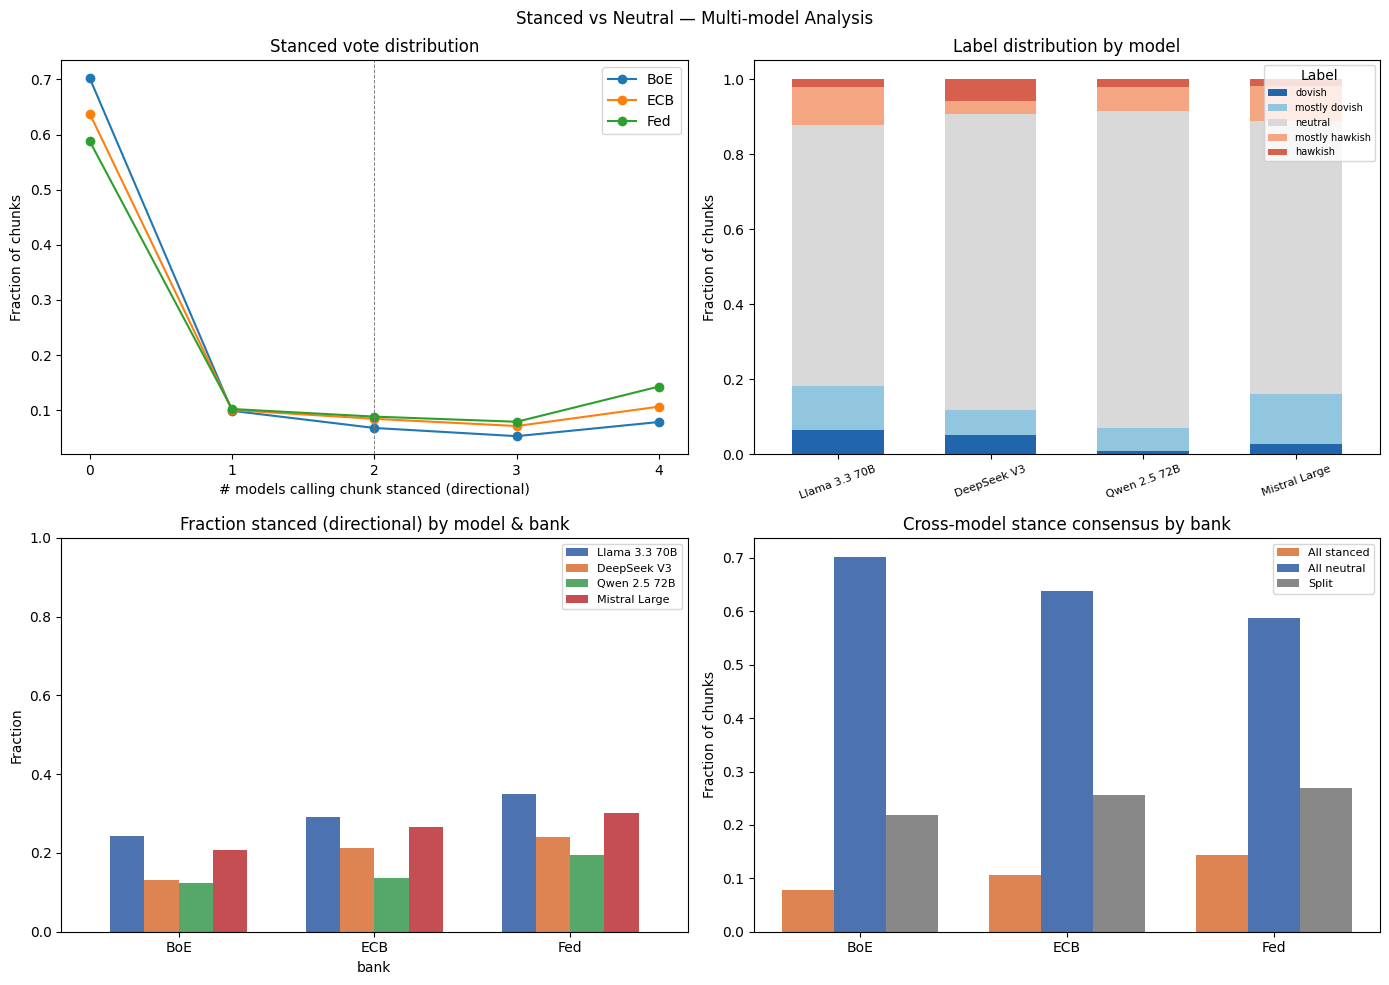

In [9]:
label_order  = ['dovish', 'mostly dovish', 'neutral', 'mostly hawkish', 'hawkish']
label_colors = ['#2166ac', '#92c5de', '#d9d9d9', '#f4a582', '#d6604d']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. How many models call each chunk stanced
ax = axes[0, 0]
for bank in BANKS:
    bdf = chunks_wide[chunks_wide['bank'] == bank]
    counts = bdf['n_stanced'].value_counts(normalize=True).sort_index()
    ax.plot(counts.index, counts.values, marker='o', label=bank)
ax.set_xlabel('# models calling chunk stanced (directional)')
ax.set_ylabel('Fraction of chunks')
ax.set_title('Stanced vote distribution')
ax.set_xticks(range(len(loaded) + 1))
ax.axvline(len(loaded) / 2, color='grey', linestyle='--', linewidth=0.7)
ax.legend()

# 2. Label distribution per model (stacked bar)
ax = axes[0, 1]
label_dist = pd.DataFrame({
    MODELS[k]['label']: chunks_wide[f'label_{k}']
        .value_counts(normalize=True).reindex(label_order).fillna(0)
    for k in loaded
}).T
label_dist.plot(kind='bar', stacked=True, ax=ax, color=label_colors, width=0.6)
ax.set_ylabel('Fraction of chunks')
ax.set_title('Label distribution by model')
ax.tick_params(axis='x', rotation=20, labelsize=8)
ax.legend(loc='upper right', fontsize=7, title='Label')

# 3. Stanced rate by model x bank
ax = axes[1, 0]
stanced_rates = pd.DataFrame({
    MODELS[k]['label']: chunks_wide.groupby('bank')[f'stanced_{k}'].mean()
    for k in loaded
}).reindex(BANKS)
stanced_rates.plot(kind='bar', ax=ax,
                   color=[MODELS[k]['color'] for k in loaded], width=0.7)
ax.set_title('Fraction stanced (directional) by model & bank')
ax.set_ylabel('Fraction')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8)
ax.set_ylim(0, 1)

# 4. Consensus breakdown by bank
ax = axes[1, 1]
summary = chunks_wide.groupby('bank').agg(
    all_stanced=('consensus_stanced', 'mean'),
    all_neutral=('consensus_neutral', 'mean'),
    split=('split', 'mean'),
).reindex(BANKS)
x = np.arange(len(BANKS))
w = 0.25
ax.bar(x - w, summary['all_stanced'], w, label='All stanced', color='#DD8452')
ax.bar(x,     summary['all_neutral'],  w, label='All neutral',  color='#4C72B0')
ax.bar(x + w, summary['split'],        w, label='Split',        color='#888888')
ax.set_xticks(x)
ax.set_xticklabels(BANKS)
ax.set_ylabel('Fraction of chunks')
ax.set_title('Cross-model stance consensus by bank')
ax.legend(fontsize=8)

plt.suptitle('Stanced vs Neutral — Multi-model Analysis', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'stanced_neutral_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4–8. Pairwise deep-dive

Change `key_a` / `key_b` in the cell below to compare any two loaded models.
Sections 4–8 (temporal, turning, delta, embeddings, logit) all use this selection.

In [10]:
# ── Pair selector ─────────────────────────────────────────────────────────────
# Change key_a / key_b to compare any two models in `loaded`
key_a, key_b = loaded[0], loaded[1]

label_a  = MODELS[key_a]['label']
label_b  = MODELS[key_b]['label']
out_name = f'{key_a}_{key_b}'

pair_cols = ['chunk_uid', 'bank', 'doc_id', 'date', 'turn_type', 'speaker_role',
             'doc_type', 'turn_idx', 'chunk_id', 'start_sent_idx',
             'end_sent_idx', 'n_sentences', 'text',
             f'label_{key_a}', f'score_{key_a}',
             f'label_{key_b}', f'score_{key_b}']

merged = chunks_wide[pair_cols].copy()
merged['same_label']    = merged[f'label_{key_a}'] == merged[f'label_{key_b}']
merged['abs_score_gap'] = (merged[f'score_{key_a}'] - merged[f'score_{key_b}']).abs()

print(f'Pair: {label_a}  vs  {label_b}')
print(f'Agreement: {merged["same_label"].mean():.1%}  |  Mean score gap: {merged["abs_score_gap"].mean():.3f}')
print()
print(merged.groupby('bank').agg(
    n_chunks=('chunk_uid', 'size'),
    agreement_rate=('same_label', 'mean'),
    mean_score_gap=('abs_score_gap', 'mean'),
).round(3))

Pair: Llama 3.3 70B  vs  DeepSeek V3
Agreement: 77.7%  |  Mean score gap: 0.131

      n_chunks  agreement_rate  mean_score_gap
bank                                          
BoE        739           0.816           0.104
ECB       2445           0.787           0.131
Fed       1813           0.747           0.142


## 4. Temporal disagreement — meeting-level score gap

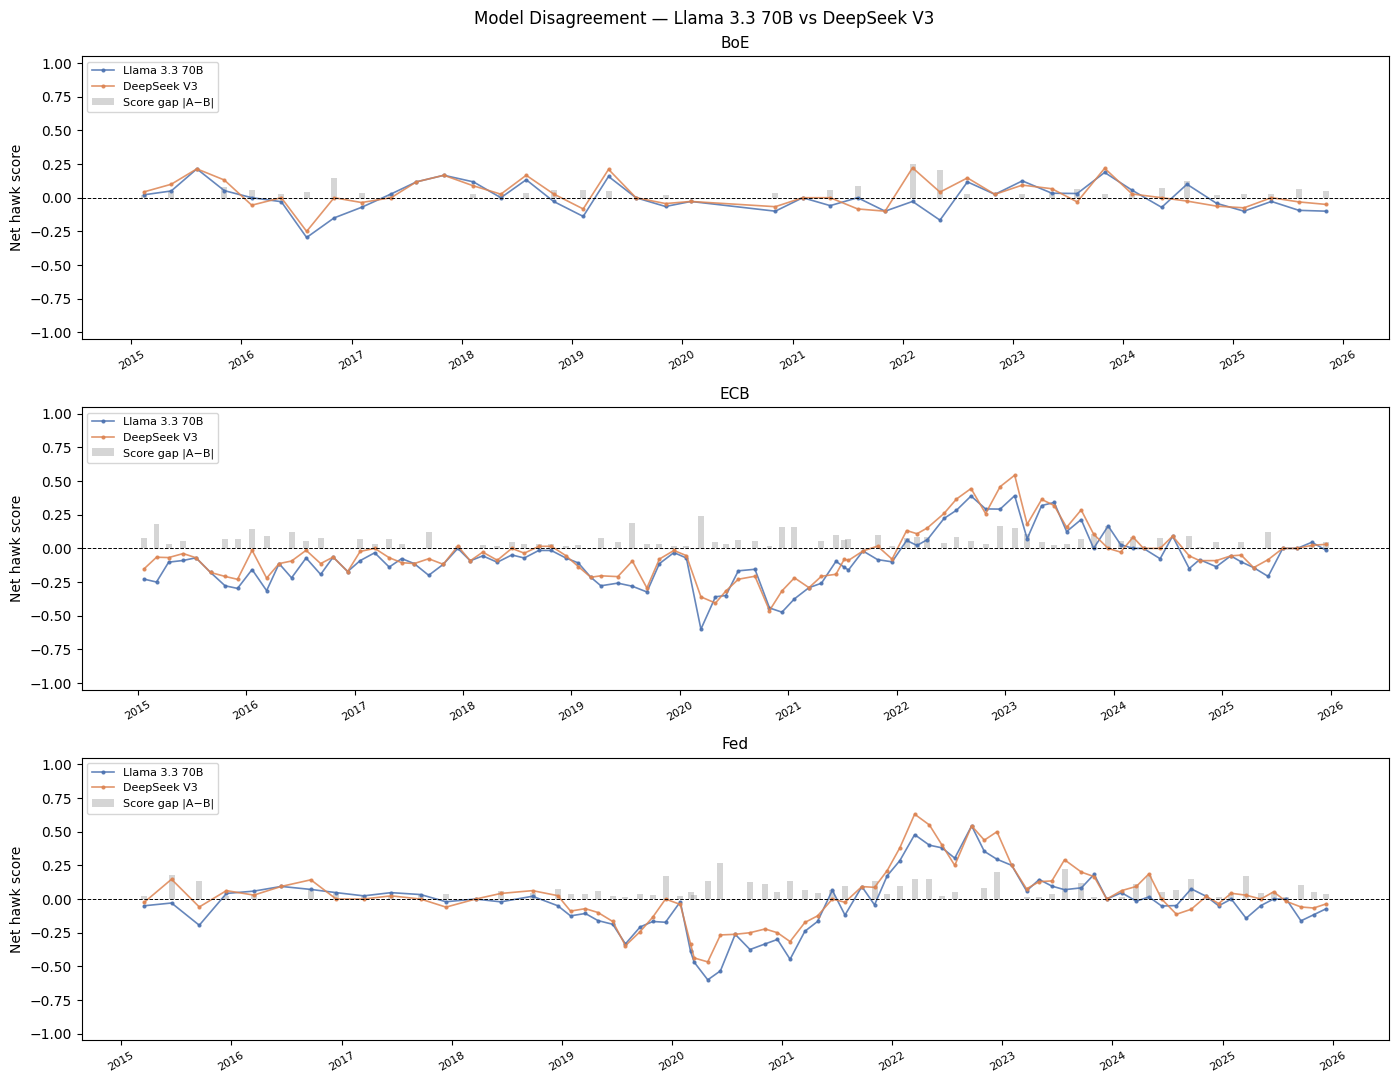

Meetings with largest score gap:
bank       date  llama33  deepseekv3  score_gap
 Fed 2020-06-10   -0.533      -0.267      0.267
 BoE 2022-02-03   -0.028       0.222      0.250
 ECB 2020-03-12   -0.600      -0.360      0.240
 Fed 2023-07-26    0.069       0.292      0.222
 BoE 2022-05-05   -0.167       0.042      0.208
 Fed 2022-12-14    0.295       0.500      0.205
 ECB 2019-07-25   -0.281      -0.094      0.188
 ECB 2015-03-05   -0.250      -0.066      0.184
 Fed 2015-06-17   -0.029       0.147      0.176
 Fed 2019-12-11   -0.172       0.000      0.172


C:\Users\sffra\AppData\Local\Temp\ipykernel_2556\3164616122.py:31: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(wide.nlargest(10, 'score_gap')[['bank','date',key_a,key_b,'score_gap']].round(3).to_string(index=False))


In [11]:
if len(loaded) >= 2:
    wide = all_meetings[key_a][['bank','doc_id','date','net_hawk']].rename(columns={'net_hawk': key_a})
    wide = wide.merge(
        all_meetings[key_b][['bank','doc_id','date','net_hawk']].rename(columns={'net_hawk': key_b}),
        on=['bank','doc_id','date'],
    )
    wide['score_gap'] = (wide[key_a] - wide[key_b]).abs()
    wide = wide.sort_values(['bank','date'])

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
    for ax, bank in zip(axes, BANKS):
        bdf = wide[wide['bank'] == bank].sort_values('date')
        ax.bar(bdf['date'], bdf['score_gap'], width=20, color='#888', alpha=0.35, label='Score gap |A−B|')
        for key, meta in {key_a: MODELS[key_a], key_b: MODELS[key_b]}.items():
            ax.plot(bdf['date'], bdf[key], color=meta['color'], linewidth=1.2,
                    marker='o', markersize=2, label=meta['label'], alpha=0.85)
        ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
        ax.set_title(bank, fontsize=11)
        ax.set_ylabel('Net hawk score')
        ax.set_ylim(-1.05, 1.05)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.legend(fontsize=8, loc='upper left')
    plt.suptitle(f'Model Disagreement — {label_a} vs {label_b}', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'timeseries_disagreement_{out_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Meetings with largest score gap:')
    print(wide.nlargest(10, 'score_gap')[['bank','date',key_a,key_b,'score_gap']].round(3).to_string(index=False))

## 5. Turning point agreement

In [12]:
if len(loaded) >= 2:
    def label_turns(values):
        vals = list(values)
        out = []
        for i in range(len(vals)):
            if i == 0 or i == len(vals) - 1:
                out.append('edge')
            elif vals[i] > vals[i-1] and vals[i] > vals[i+1]:
                out.append('peak')
            elif vals[i] < vals[i-1] and vals[i] < vals[i+1]:
                out.append('trough')
            else:
                out.append('none')
        return out

    turn_df = wide.copy()
    turn_df[f'turn_{key_a}'] = turn_df.groupby('bank')[key_a].transform(label_turns)
    turn_df[f'turn_{key_b}'] = turn_df.groupby('bank')[key_b].transform(label_turns)
    turn_df['same_turn']   = turn_df[f'turn_{key_a}'] == turn_df[f'turn_{key_b}']
    turn_df['either_turn'] = (
        turn_df[f'turn_{key_a}'].isin(['peak','trough']) |
        turn_df[f'turn_{key_b}'].isin(['peak','trough'])
    )

    print(f'=== Turning point agreement: {label_a} vs {label_b} ===')
    print(turn_df.groupby('bank').agg(
        n_meetings=('doc_id','size'),
        turns_a=(f'turn_{key_a}', lambda x: x.isin(['peak','trough']).sum()),
        turns_b=(f'turn_{key_b}', lambda x: x.isin(['peak','trough']).sum()),
        turn_match_rate=('same_turn','mean'),
    ).round(3))

    mismatches = turn_df[turn_df['either_turn'] & ~turn_df['same_turn']].copy()
    mismatches['gap'] = (mismatches[key_a] - mismatches[key_b]).abs()
    print(f'\nMismatches: {len(mismatches)}')
    print(mismatches[['bank','date',f'turn_{key_a}',f'turn_{key_b}',key_a,key_b,'gap']]
          .sort_values(['bank','date']).round(3).to_string(index=False))

=== Turning point agreement: Llama 3.3 70B vs DeepSeek V3 ===
      n_meetings  turns_a  turns_b  turn_match_rate
bank                                               
BoE           42       25       24            0.786
ECB           89       52       50            0.506
Fed           73       41       35            0.589

Mismatches: 83
bank       date turn_llama33 turn_deepseekv3  llama33  deepseekv3   gap
 BoE 2016-02-04         none          trough    0.000      -0.056 0.056
 BoE 2016-05-12         none            peak   -0.029       0.000 0.029
 BoE 2016-11-03         none            peak   -0.150       0.000 0.150
 BoE 2017-02-02         none          trough   -0.071      -0.036 0.036
 BoE 2021-02-04         peak            none    0.000       0.000 0.000
 BoE 2021-05-06       trough            none   -0.059       0.000 0.059
 BoE 2021-08-05         peak            none    0.000      -0.083 0.083
 BoE 2024-05-09       trough            none   -0.071       0.000 0.071
 BoE 2024-08-0

C:\Users\sffra\AppData\Local\Temp\ipykernel_2556\918248717.py:37: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .sort_values(['bank','date']).round(3).to_string(index=False))


## 6. Delta/shift analysis — meeting-to-meeting changes

=== Delta summary by bank ===
      mean_level_gap  mean_shift_gap  same_shift_dir_rate
bank                                                     
BoE            0.048           0.064                0.878
ECB            0.057           0.069                0.693
Fed            0.067           0.075                0.736


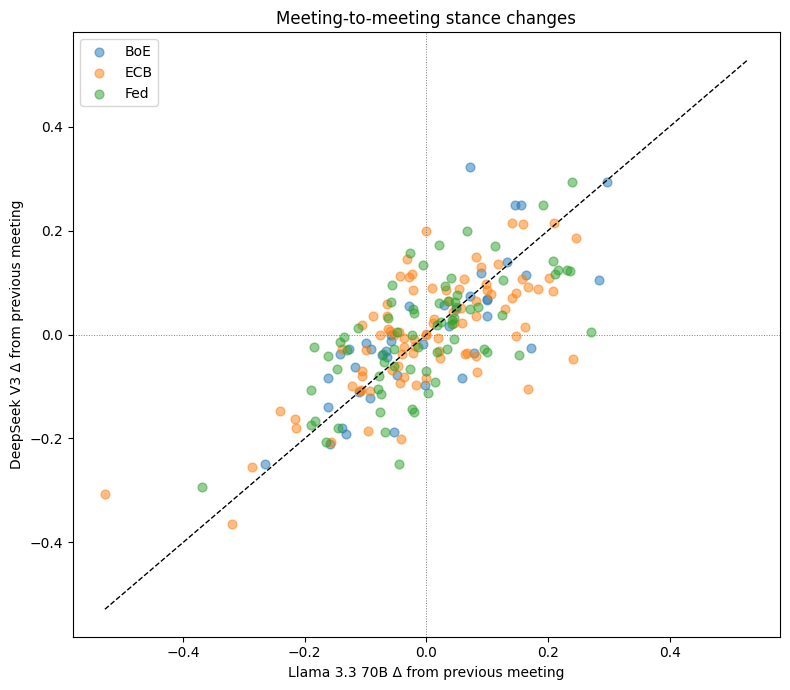

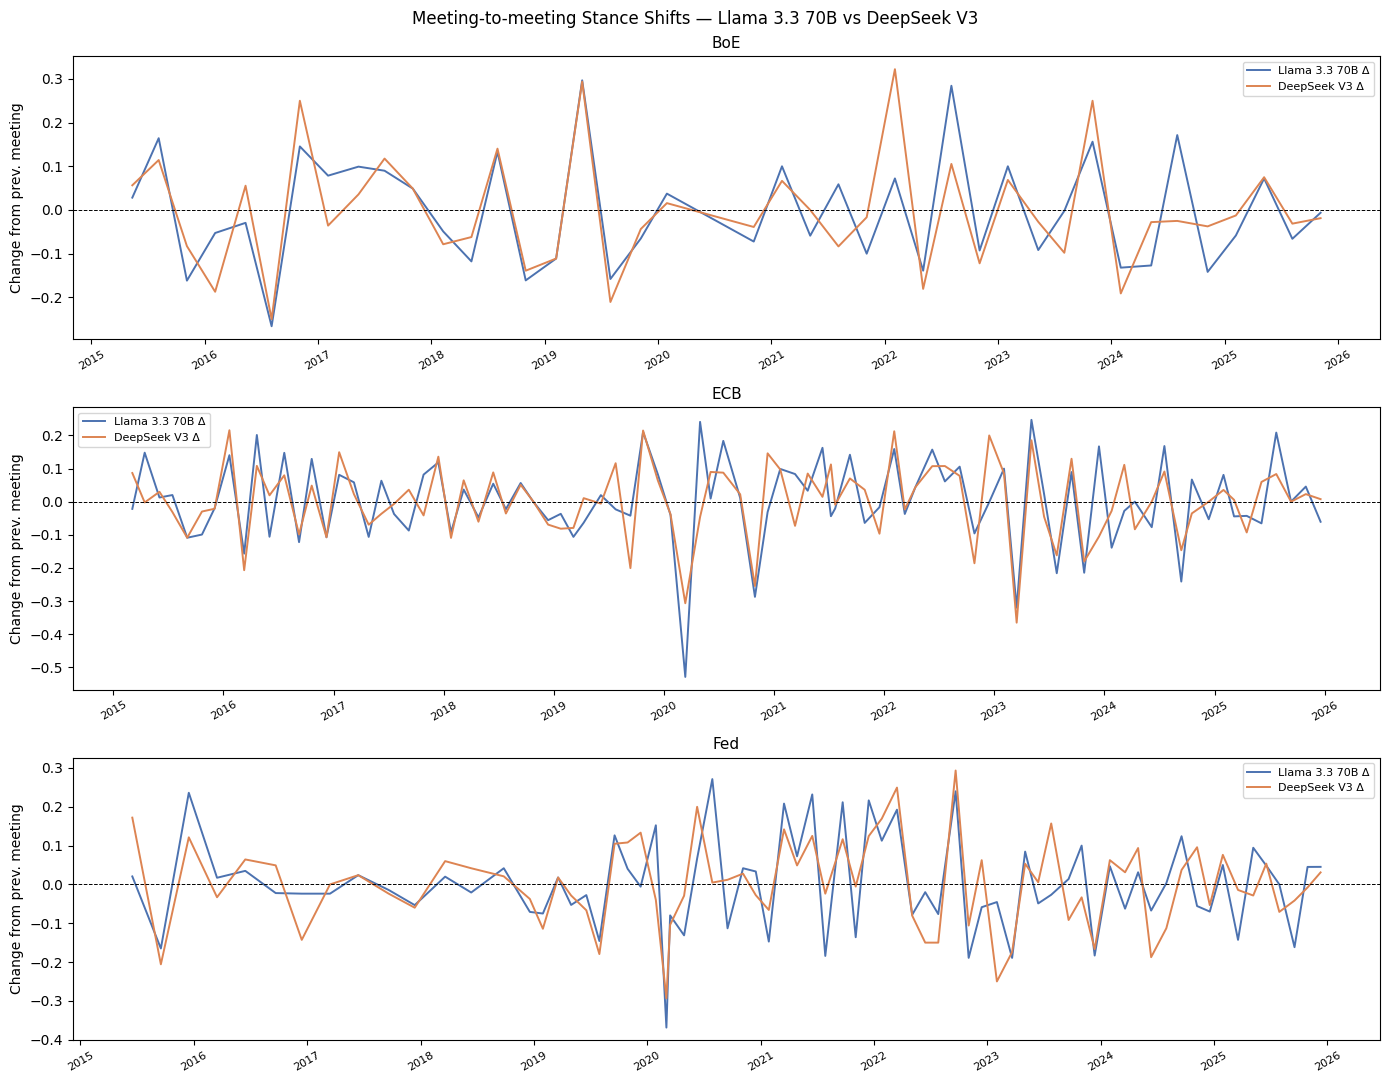


Meetings with largest shift disagreement:
bank       date  delta_llama33  delta_deepseekv3  shift_gap
 ECB 2020-04-30          0.241            -0.046      0.287
 ECB 2023-12-14          0.167            -0.105      0.272
 Fed 2020-07-29          0.271             0.005      0.267
 BoE 2022-02-03          0.072             0.322      0.250
 ECB 2020-03-12         -0.529            -0.306      0.222
 Fed 2023-02-01         -0.045            -0.250      0.205
 ECB 2022-12-15         -0.001             0.200      0.201
 BoE 2024-08-01          0.171            -0.025      0.196
 Fed 2020-01-29          0.152            -0.040      0.192
 Fed 2023-07-26         -0.027             0.157      0.184


C:\Users\sffra\AppData\Local\Temp\ipykernel_2556\812698450.py:57: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(wide.nlargest(10, 'shift_gap')[['bank','date',f'delta_{key_a}',f'delta_{key_b}','shift_gap']].round(3).to_string(index=False))


In [13]:
if len(loaded) >= 2:
    wide[f'delta_{key_a}'] = wide.groupby('bank')[key_a].diff()
    wide[f'delta_{key_b}'] = wide.groupby('bank')[key_b].diff()
    wide['shift_gap'] = (wide[f'delta_{key_a}'] - wide[f'delta_{key_b}']).abs()
    wide['same_shift_dir'] = np.where(
        wide[f'delta_{key_a}'].notna() & wide[f'delta_{key_b}'].notna(),
        np.sign(wide[f'delta_{key_a}']) == np.sign(wide[f'delta_{key_b}']),
        pd.NA,
    )

    shift_df = wide.dropna(subset=['shift_gap'])
    print('=== Delta summary by bank ===')
    print(shift_df.groupby('bank').agg(
        mean_level_gap=('score_gap','mean'),
        mean_shift_gap=('shift_gap','mean'),
        same_shift_dir_rate=('same_shift_dir', lambda x: pd.Series(x).dropna().astype(bool).mean()),
    ).round(3))

    # Scatter: delta_a vs delta_b
    plt.figure(figsize=(8, 7))
    for bank in BANKS:
        bdf = shift_df[shift_df['bank'] == bank]
        plt.scatter(bdf[f'delta_{key_a}'], bdf[f'delta_{key_b}'], label=bank, alpha=0.5, s=40)
    lim = max(shift_df[[f'delta_{key_a}',f'delta_{key_b}']].abs().max())
    plt.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1)
    plt.axhline(0, color='grey', linewidth=0.7, linestyle=':')
    plt.axvline(0, color='grey', linewidth=0.7, linestyle=':')
    plt.xlabel(f'{label_a} Δ from previous meeting')
    plt.ylabel(f'{label_b} Δ from previous meeting')
    plt.title('Meeting-to-meeting stance changes')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'timeseries_delta_scatter_{out_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Time series of deltas by bank
    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
    for ax, bank in zip(axes, BANKS):
        bdf = shift_df[shift_df['bank'] == bank].sort_values('date')
        ax.plot(bdf['date'], bdf[f'delta_{key_a}'], color=MODELS[key_a]['color'],
                linewidth=1.4, label=f'{label_a} Δ')
        ax.plot(bdf['date'], bdf[f'delta_{key_b}'], color=MODELS[key_b]['color'],
                linewidth=1.4, label=f'{label_b} Δ')
        ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
        ax.set_title(bank, fontsize=11)
        ax.set_ylabel('Change from prev. meeting')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.legend(fontsize=8)
    plt.suptitle(f'Meeting-to-meeting Stance Shifts — {label_a} vs {label_b}', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'timeseries_delta_{out_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nMeetings with largest shift disagreement:')
    print(wide.nlargest(10, 'shift_gap')[['bank','date',f'delta_{key_a}',f'delta_{key_b}','shift_gap']].round(3).to_string(index=False))

## 7. Semantic space — where does stanced/neutral disagreement live?

Embeds all chunks and projects to 2D. Colors show cross-model stanced/neutral consensus.
Split chunks (where models disagree on stanced vs neutral) are highlighted on the right.
Uses `sentence-transformers/all-MiniLM-L6-v2` with TF-IDF + SVD fallback.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Representation: sentence-transformer + PCA
stance_group
all neutral               3145
split — mostly neutral     919
all stanced                577
split — mostly stanced     356
Name: count, dtype: int64


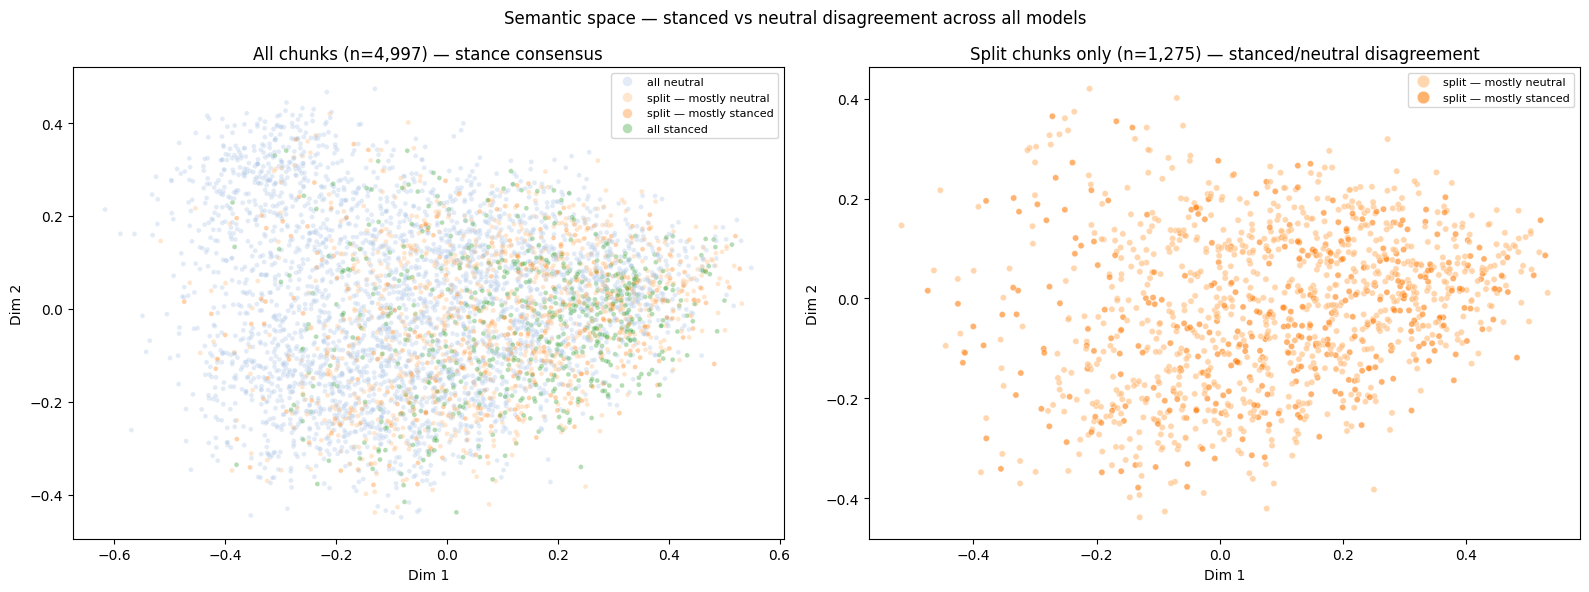

In [14]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

# Stance consensus category across all loaded models
def stance_category(n_stanced, n_models):
    if n_stanced == 0:
        return 'all neutral'
    elif n_stanced == n_models:
        return 'all stanced'
    elif n_stanced <= n_models // 2:
        return 'split — mostly neutral'
    else:
        return 'split — mostly stanced'

repr_df = chunks_wide.copy()
repr_df['stance_group'] = repr_df['n_stanced'].apply(
    lambda n: stance_category(n, len(loaded))
)

texts = repr_df['text'].fillna('').tolist()
rep_source = 'tfidf_svd'
try:
    from sentence_transformers import SentenceTransformer
    enc = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    emb = enc.encode(texts, show_progress_bar=True)
    rep_2d = PCA(n_components=2, random_state=42).fit_transform(emb)
    rep_source = 'sentence-transformer + PCA'
except Exception as e:
    print(f'Falling back to TF-IDF+SVD: {e}')
    tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
    X = tfidf.fit_transform(texts)
    rep_2d = TruncatedSVD(n_components=2, random_state=42).fit_transform(X)

repr_df['rep_x'] = rep_2d[:, 0]
repr_df['rep_y'] = rep_2d[:, 1]
print(f'Representation: {rep_source}')
print(repr_df['stance_group'].value_counts())

group_order = ['all neutral', 'split — mostly neutral', 'split — mostly stanced', 'all stanced']
palette = {
    'all neutral':           '#aec7e8',
    'split — mostly neutral': '#ffbb78',
    'split — mostly stanced': '#ff7f0e',
    'all stanced':            '#2ca02c',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: all chunks
sns.scatterplot(data=repr_df, x='rep_x', y='rep_y', hue='stance_group',
                hue_order=group_order, palette=palette,
                alpha=0.35, s=12, ax=axes[0])
axes[0].set_title(f'All chunks (n={len(repr_df):,}) — stance consensus')
axes[0].set_xlabel('Dim 1'); axes[0].set_ylabel('Dim 2')
axes[0].legend(fontsize=8, markerscale=2)

# Right: split chunks only (where models disagree on stanced vs neutral)
split_df = repr_df[repr_df['split']].copy()
sns.scatterplot(data=split_df, x='rep_x', y='rep_y', hue='stance_group',
                hue_order=[g for g in group_order if 'split' in g],
                palette=palette, alpha=0.6, s=20, ax=axes[1])
axes[1].set_title(f'Split chunks only (n={len(split_df):,}) — stanced/neutral disagreement')
axes[1].set_xlabel('Dim 1'); axes[1].set_ylabel('Dim 2')
axes[1].legend(fontsize=8, markerscale=2)

plt.suptitle('Semantic space — stanced vs neutral disagreement across all models', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'representation_space_stanced_neutral.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. What predicts stanced/neutral disagreement?

Logistic regression: which chunk features predict whether models *split* on stanced vs neutral?
Target = `split` (True when at least one model says stanced and at least one says neutral).
Uses all loaded models via `chunks_wide`.

C:\Users\sffra\AppData\Local\Temp\ipykernel_2556\4240874711.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  model_df[col] = model_df['text'].str.contains(pat, case=False, regex=True, na=False).astype(int)
C:\Users\sffra\AppData\Local\Temp\ipykernel_2556\4240874711.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  model_df[col] = model_df['text'].str.contains(pat, case=False, regex=True, na=False).astype(int)
C:\Users\sffra\AppData\Local\Temp\ipykernel_2556\4240874711.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  model_df[col] = model_df['text'].str.contains(pat, case=False, regex=True, na=False).astype(int)
C:\Users\sffra\AppData\Local\Temp\ipykernel_2556\4240874711.py:22: UserWarning: This pattern is interpr

In-sample ROC AUC: 0.663  (split prevalence: 25.5%, n=1,275)


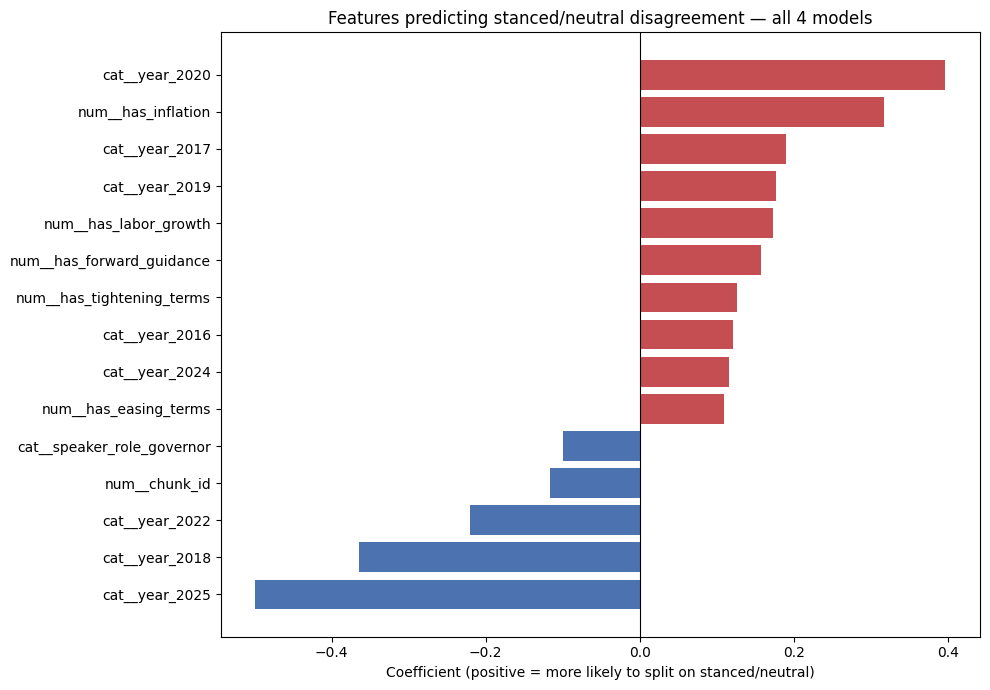


Top features by absolute coefficient:
                   feature   coef
            cat__year_2025 -0.499
            cat__year_2020  0.397
            cat__year_2018 -0.364
        num__has_inflation  0.317
            cat__year_2022 -0.221
            cat__year_2017  0.190
            cat__year_2019  0.176
     num__has_labor_growth  0.173
 num__has_forward_guidance  0.157
 num__has_tightening_terms  0.126
            cat__year_2016  0.121
             num__chunk_id -0.116
            cat__year_2024  0.115
     num__has_easing_terms  0.109
cat__speaker_role_governor -0.100


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_df = chunks_wide.copy()
model_df['split_target'] = model_df['split'].astype(int)
model_df['word_count']   = model_df['text'].str.split().str.len()
model_df['year']         = model_df['date'].dt.year.astype(str)

PATTERNS = {
    'has_forward_guidance': r'\b(will|would|expect|likely|path|trajectory|going forward)\b',
    'has_contrast_markers': r'\b(but|however|although|while|on the other hand)\b',
    'has_inflation':        r'\b(inflation|prices|price stability|disinflation)\b',
    'has_labor_growth':     r'\b(growth|activity|demand|employment|labou?r market)\b',
    'has_risk_language':    r'\b(risk|uncertainty|upside|downside|balance of risks)\b',
    'has_tightening_terms': r'\b(higher rates|raise rates|tighten|restrictive|hike)\b',
    'has_easing_terms':     r'\b(cut rates|lower rates|ease|accommodation|stimulus|qe)\b',
}
for col, pat in PATTERNS.items():
    model_df[col] = model_df['text'].str.contains(pat, case=False, regex=True, na=False).astype(int)

num_cols = ['word_count', 'n_sentences', 'turn_idx', 'chunk_id'] + list(PATTERNS.keys())
cat_cols = ['bank', 'speaker_role', 'turn_type', 'doc_type', 'year']

X = model_df[num_cols + cat_cols].copy()
y = model_df['split_target']

clf = Pipeline([
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])),
    ('logit', LogisticRegression(max_iter=5000, class_weight='balanced')),
])
clf.fit(X, y)

auc = roc_auc_score(y, clf.predict_proba(X)[:, 1])
print(f'In-sample ROC AUC: {auc:.3f}  (split prevalence: {y.mean():.1%}, n={y.sum():,})')

feat_names = clf.named_steps['prep'].get_feature_names_out()
coef_df = pd.DataFrame({'feature': feat_names, 'coef': clf.named_steps['logit'].coef_[0]})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

plt.figure(figsize=(10, 7))
top = coef_df.head(15).sort_values('coef')
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in top['coef']]
plt.barh(top['feature'], top['coef'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (positive = more likely to split on stanced/neutral)')
plt.title(f'Features predicting stanced/neutral disagreement — all {len(loaded)} models')
plt.tight_layout()
plt.savefig(OUT_DIR / 'disagreement_features_stanced_neutral.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop features by absolute coefficient:')
print(coef_df.head(15)[['feature', 'coef']].round(3).to_string(index=False))

C:\Users\sffra\AppData\Local\Temp\ipykernel_2556\1650928703.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  model_df2[col] = model_df2['text'].str.contains(pat, case=False, regex=True, na=False).astype(int)
C:\Users\sffra\AppData\Local\Temp\ipykernel_2556\1650928703.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  model_df2[col] = model_df2['text'].str.contains(pat, case=False, regex=True, na=False).astype(int)
C:\Users\sffra\AppData\Local\Temp\ipykernel_2556\1650928703.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  model_df2[col] = model_df2['text'].str.contains(pat, case=False, regex=True, na=False).astype(int)
C:\Users\sffra\AppData\Local\Temp\ipykernel_2556\1650928703.py:13: UserWarning: This pattern is i

AUC with year FE:    0.663
AUC without year FE: 0.650
AUC drop from removing year: 0.013

Linguistic feature coefficients — with vs without year FE:
         feature  coef_no_year  coef_with_year
       inflation         0.293           0.317
    labor_growth         0.171           0.173
forward_guidance         0.156           0.157
    easing_terms         0.123           0.109
tightening_terms         0.112           0.126
contrast_markers         0.024           0.034
   risk_language         0.008           0.017


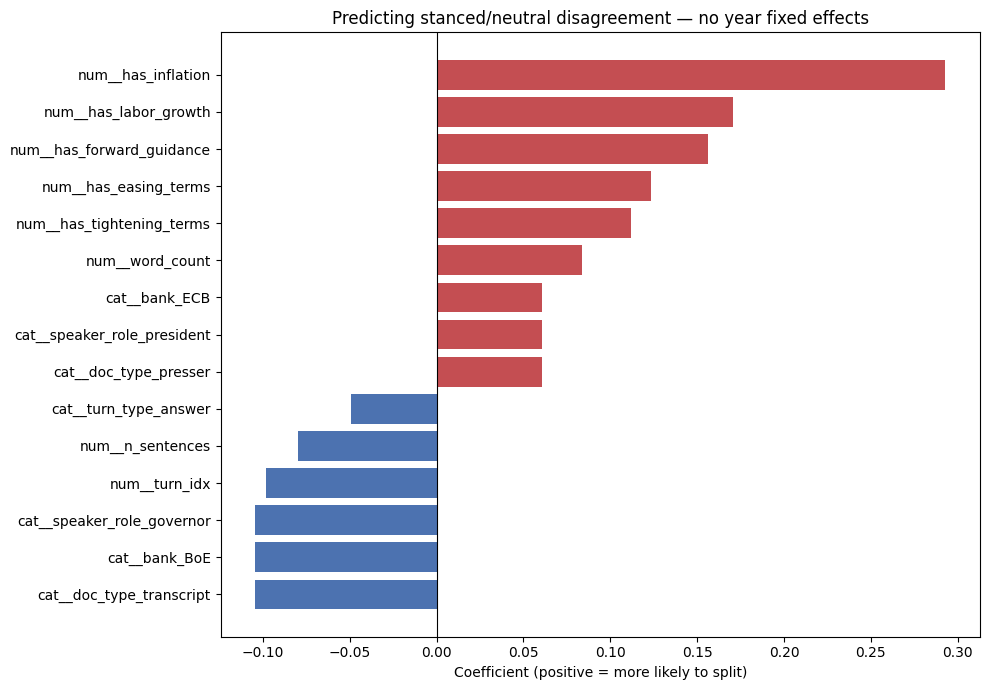

In [16]:
# ── Logit without year FE: do linguistic features absorb regime ambiguity? ────
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_df2 = chunks_wide.copy()
model_df2['split_target'] = model_df2['split'].astype(int)
model_df2['word_count']   = model_df2['text'].str.split().str.len()

for col, pat in PATTERNS.items():
    model_df2[col] = model_df2['text'].str.contains(pat, case=False, regex=True, na=False).astype(int)

num_cols = ['word_count', 'n_sentences', 'turn_idx', 'chunk_id'] + list(PATTERNS.keys())
cat_cols = ['bank', 'speaker_role', 'turn_type', 'doc_type']  # no year

X2 = model_df2[num_cols + cat_cols].copy()
y2 = model_df2['split_target']

clf2 = Pipeline([
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])),
    ('logit', LogisticRegression(max_iter=5000, class_weight='balanced')),
])
clf2.fit(X2, y2)

auc_with    = roc_auc_score(y,  clf.predict_proba(X)[:, 1])   # from previous cell
auc_without = roc_auc_score(y2, clf2.predict_proba(X2)[:, 1])
print(f'AUC with year FE:    {auc_with:.3f}')
print(f'AUC without year FE: {auc_without:.3f}')
print(f'AUC drop from removing year: {auc_with - auc_without:.3f}')
print()

feat_names2 = clf2.named_steps['prep'].get_feature_names_out()
coef_df2 = pd.DataFrame({'feature': feat_names2, 'coef': clf2.named_steps['logit'].coef_[0]})
coef_df2['abs_coef'] = coef_df2['coef'].abs()
coef_df2 = coef_df2.sort_values('abs_coef', ascending=False)

# Side-by-side: with vs without year, linguistic features only
ling_features = ['num__' + c for c in PATTERNS.keys()]
comp = coef_df2[coef_df2['feature'].isin(ling_features)][['feature', 'coef']].rename(
    columns={'coef': 'coef_no_year'}
).merge(
    coef_df[coef_df['feature'].isin(ling_features)][['feature', 'coef']].rename(
        columns={'coef': 'coef_with_year'}
    ),
    on='feature'
).sort_values('coef_no_year', ascending=False)
comp['feature'] = comp['feature'].str.replace('num__has_', '')
print('Linguistic feature coefficients — with vs without year FE:')
print(comp.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# Plot: no-year model full top-15
plt.figure(figsize=(10, 7))
top2 = coef_df2.head(15).sort_values('coef')
colors2 = ['#C44E52' if c > 0 else '#4C72B0' for c in top2['coef']]
plt.barh(top2['feature'], top2['coef'], color=colors2)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (positive = more likely to split)')
plt.title('Predicting stanced/neutral disagreement — no year fixed effects')
plt.tight_layout()
plt.savefig(OUT_DIR / 'disagreement_features_no_year.png', dpi=150, bbox_inches='tight')
plt.show()


c:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\.venv\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
Background dataset has 4997 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4997 when initializing the masker.


In-sample AUC:  0.784
5-fold CV AUC:  0.674 ± 0.035
Keyword logit:  0.645  (baseline)

Top 20 split-inducing tokens:
          token  mean_shap
      countries     0.0091
       decision     0.0071
         strong     0.0071
             ll     0.0062
      beginning     0.0055
       increase     0.0055
          lower     0.0054
        banking     0.0052
          asset     0.0049
        lending     0.0048
      necessary     0.0048
      carefully     0.0045
asset purchases     0.0044
       progress     0.0043
       evidence     0.0041
       continue     0.0039
      purchases     0.0036
          sheet     0.0033
          terms     0.0033
        markets     0.0032

Top 20 consensus-inducing tokens:
      token  mean_shap
  inflation    -0.0169
    support    -0.0162
    economy    -0.0122
  certainly    -0.0105
  sustained    -0.0072
   activity    -0.0062
   recovery    -0.0060
     saying    -0.0059
   question    -0.0056
    comment    -0.0054
     months    -0.0054
instr

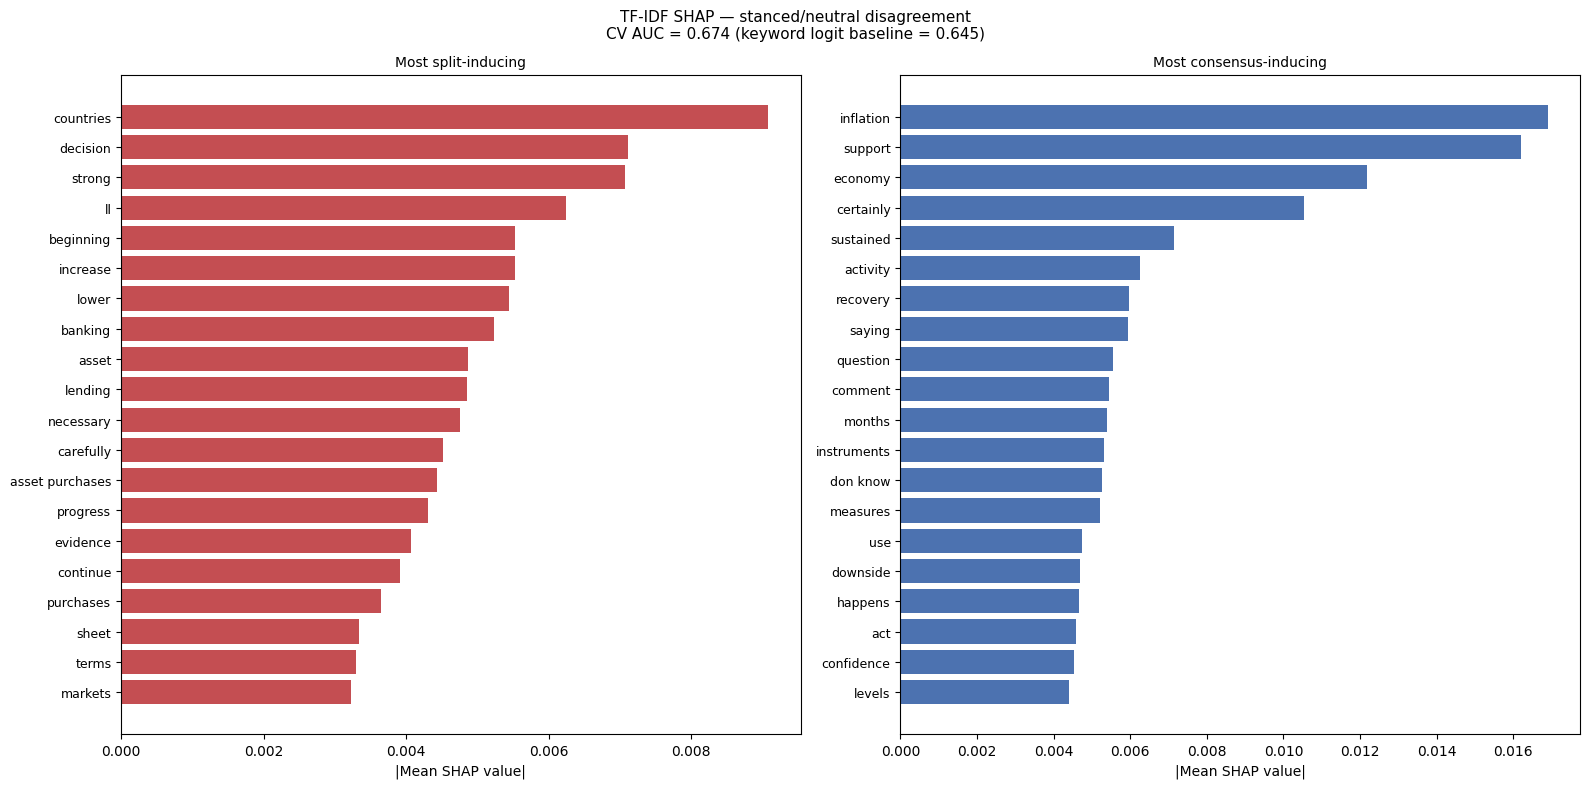

In [17]:
# ── SHAP on TF-IDF (corrected): stop words, tighter vocab, cross-validated ───
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
import shap

texts  = chunks_wide['text'].fillna('').tolist()
target = chunks_wide['split'].astype(int).values

tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=10,
    stop_words='english',
    sublinear_tf=True,
)
X_tfidf = tfidf.fit_transform(texts)

clf_tfidf = LogisticRegression(max_iter=2000, class_weight='balanced', C=0.5)
clf_tfidf.fit(X_tfidf, target)

auc_insample = roc_auc_score(target, clf_tfidf.predict_proba(X_tfidf)[:, 1])
cv_auc = cross_val_score(clf_tfidf, X_tfidf, target, cv=5, scoring='roc_auc')
print(f'In-sample AUC:  {auc_insample:.3f}')
print(f'5-fold CV AUC:  {cv_auc.mean():.3f} ± {cv_auc.std():.3f}')
print(f'Keyword logit:  0.645  (baseline)')
print()

# SHAP
explainer   = shap.LinearExplainer(clf_tfidf, X_tfidf, feature_perturbation='interventional')
shap_values = explainer.shap_values(X_tfidf)

feature_names = tfidf.get_feature_names_out()
mean_shap     = shap_values.mean(axis=0)

shap_df = pd.DataFrame({'token': feature_names, 'mean_shap': mean_shap})
shap_df['abs_shap'] = shap_df['mean_shap'].abs()
shap_df = shap_df.sort_values('mean_shap', ascending=False)

print('Top 20 split-inducing tokens:')
print(shap_df.head(20)[['token','mean_shap']].to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print()
print('Top 20 consensus-inducing tokens:')
print(shap_df.tail(20)[['token','mean_shap']].iloc[::-1].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, df_sub, label, color in [
    (axes[0], shap_df.head(20),              'Most split-inducing',    '#C44E52'),
    (axes[1], shap_df.tail(20).iloc[::-1],   'Most consensus-inducing','#4C72B0'),
]:
    ax.barh(df_sub['token'], df_sub['mean_shap'].abs(), color=color)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('|Mean SHAP value|')
    ax.tick_params(axis='y', labelsize=9)
    ax.invert_yaxis()

plt.suptitle(
    f'TF-IDF SHAP — stanced/neutral disagreement\n'
    f'CV AUC = {cv_auc.mean():.3f} (keyword logit baseline = 0.645)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'shap_tfidf_corrected.png', dpi=150, bbox_inches='tight')
plt.show()


=== Hedge density by consensus group ===
              count    mean     std  min     25%     50%     75%     max
group                                                                   
all neutral  3138.0  0.0181  0.0153  0.0  0.0087  0.0160  0.0246  0.1667
all stanced   582.0  0.0170  0.0110  0.0  0.0099  0.0154  0.0228  0.0741
split        1283.0  0.0191  0.0129  0.0  0.0106  0.0179  0.0252  0.1111

=== Hedge density: split vs consensus ===
Split chunks:     0.0191
Consensus chunks: 0.0179
Ratio:            1.067x


c:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for 


Hedge density logit — CV AUC: 0.567  (baseline: 0.645, SHAP TF-IDF: 0.676)


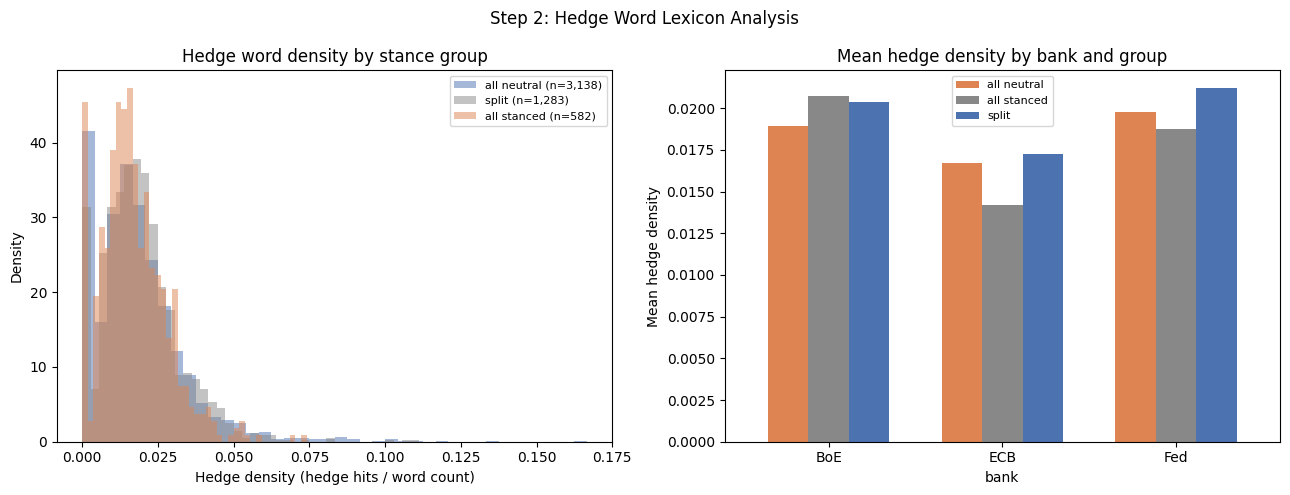

In [ ]:
# ── Step 2: Hedge word lexicon density ────────────────────────────────────────
import re
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Loughran-McDonald uncertainty + hedging words (curated subset relevant to CB speech)
HEDGE_LEXICON = [
    # Epistemic hedges
    'approximately', 'appear', 'appears', 'seem', 'seems', 'suggest', 'suggests',
    'indicate', 'indicates', 'possible', 'possibly', 'potential', 'potentially',
    'likely', 'unlikely', 'probably', 'uncertain', 'uncertainty', 'unclear',
    # Modal verbs (epistemic)
    'might', 'may', 'could', 'would', 'should',
    # Vague quantifiers
    'some', 'somewhat', 'rather', 'relatively', 'broadly',
    # Approximators
    'around', 'roughly', 'about', 'approximately',
    # Conditionality
    'if', 'depending', 'conditional', 'provided', 'subject to',
    # Forward-looking hedge phrases
    'going forward', 'in due course', 'at some point', 'over time',
    'remains to be seen', 'monitor', 'monitoring', 'vigilant',
    # CB-specific hedge phrases
    'data dependent', 'data-dependent', 'meeting by meeting',
    'gradual', 'gradually', 'cautious', 'patience', 'patient',
    'flexible', 'flexibility', 'optionality',
]

def hedge_density(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    words = text.lower().split()
    n = len(words)
    if n == 0:
        return 0.0
    hits = sum(1 for w in HEDGE_LEXICON if re.search(r'\b' + re.escape(w) + r'\b', text.lower()))
    return hits / n

hedge_df = chunks_wide.copy()
hedge_df['hedge_density']   = hedge_df['text'].apply(hedge_density)
hedge_df['hedge_count']     = hedge_df['text'].apply(
    lambda t: sum(1 for w in HEDGE_LEXICON
                  if isinstance(t, str) and re.search(r'\b' + re.escape(w) + r'\b', t.lower()))
)
hedge_df['split_target']    = hedge_df['split'].astype(int)
hedge_df['word_count']      = hedge_df['text'].str.split().str.len()

# Distribution: hedge density by consensus group
group_labels = {0: 'all neutral', len(loaded): 'all stanced'}
hedge_df['group'] = hedge_df['n_stanced'].apply(
    lambda n: 'all neutral' if n == 0 else ('all stanced' if n == len(loaded) else 'split')
)

print("=== Hedge density by consensus group ===")
print(hedge_df.groupby('group')['hedge_density'].describe().round(4))

print("\n=== Hedge density: split vs consensus ===")
split_mean  = hedge_df[hedge_df['split']]['hedge_density'].mean()
cons_mean   = hedge_df[~hedge_df['split']]['hedge_density'].mean()
print(f"Split chunks:     {split_mean:.4f}")
print(f"Consensus chunks: {cons_mean:.4f}")
print(f"Ratio:            {split_mean / cons_mean:.3f}x")

# Logit: hedge density alone
X_hedge = hedge_df[['hedge_density', 'word_count']].fillna(0).values
y_hedge = hedge_df['split_target'].values
X_hedge_s = StandardScaler().fit_transform(X_hedge)
cv_auc_hedge = cross_val_score(
    LogisticRegressionCV(cv=5, scoring='roc_auc', max_iter=1000, class_weight='balanced'),
    X_hedge_s, y_hedge, cv=5, scoring='roc_auc'
).mean()
print(f"\nHedge density logit — CV AUC: {cv_auc_hedge:.3f}  (baseline: 0.645, SHAP TF-IDF: 0.676)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: hedge density distribution by group
ax = axes[0]
for grp, color in [('all neutral', '#4C72B0'), ('split', '#888888'), ('all stanced', '#DD8452')]:
    sub = hedge_df[hedge_df['group'] == grp]['hedge_density']
    ax.hist(sub, bins=40, alpha=0.5, label=f'{grp} (n={len(sub):,})', color=color, density=True)
ax.set_xlabel('Hedge density (hedge hits / word count)')
ax.set_ylabel('Density')
ax.set_title('Hedge word density by stance group')
ax.legend(fontsize=8)

# Right: mean hedge density by bank × group
ax = axes[1]
summary = hedge_df.groupby(['bank', 'group'])['hedge_density'].mean().unstack('group')
summary.plot(kind='bar', ax=ax, color=['#DD8452', '#888888', '#4C72B0'], width=0.7)
ax.set_title('Mean hedge density by bank and group')
ax.set_ylabel('Mean hedge density')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8)

plt.suptitle('Step 2: Hedge Word Lexicon Analysis', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'hedge_lexicon_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


Parsing chunks with spaCy (may take ~1–2 min)...
Done. Feature means by group:
group               all neutral  all stanced    split
n_stanced               0.00000      4.00000  1.88309
n_weak_modal            0.00196      0.00145  0.00199
n_strong_modal          0.00939      0.01020  0.01024
n_negated_modal         0.00002      0.00000  0.00001
n_policy_verb           0.00128      0.00333  0.00270
n_modal_policy          0.00000      0.00000  0.00001
n_if_clause             0.00258      0.00324  0.00356
n_cb_subject_modal      0.00012      0.00012  0.00007

Syntactic features logit — CV AUC: 0.842
  (baseline: 0.645  |  hedge density: ~0.640  |  TF-IDF SHAP: 0.676)


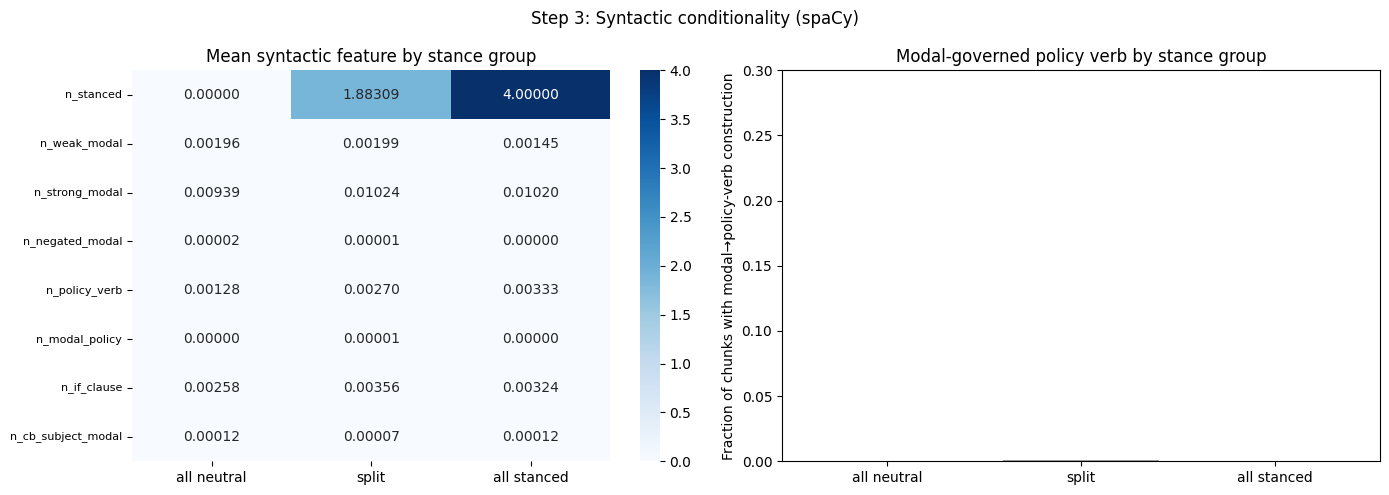

In [ ]:
# ── Step 3: Modal verb & syntactic conditionality (spaCy) ─────────────────────
import spacy

nlp = spacy.load('en_core_web_sm')

# Patterns of interest:
# 1. Modal verb as root/aux of a policy-relevant verb (raise, cut, tighten, ease, hike, lower, adjust)
# 2. Negation on a directional verb (will not raise)
# 3. Conditional structure (if ... then)
# 4. Subject of modal verb (we/I = commitment; economy/inflation = description)

POLICY_VERBS = {'raise', 'cut', 'hike', 'ease', 'tighten', 'lower', 'adjust',
                'increase', 'decrease', 'reduce', 'expand', 'contract'}
MODALS_WEAK  = {'might', 'may', 'could'}
MODALS_STRONG = {'will', 'shall', 'must', 'would'}
CB_SUBJECTS  = {'we', 'i', 'the committee', 'the council', 'the board', 'governing council'}

def parse_chunk(text):
    if not isinstance(text, str):
        return {}
    doc = nlp(text[:1000])  # cap for speed
    feats = {
        'n_weak_modal':       0,  # may/might/could
        'n_strong_modal':     0,  # will/shall/must/would
        'n_negated_modal':    0,  # won't / might not
        'n_policy_verb':      0,  # raise/cut/tighten/ease etc
        'n_modal_policy':     0,  # modal governing a policy verb
        'n_if_clause':        0,  # conditional structures
        'n_cb_subject_modal': 0,  # "we will/may/might..."
    }
    for token in doc:
        low = token.lower_
        if low in MODALS_WEAK:
            feats['n_weak_modal'] += 1
        if low in MODALS_STRONG:
            feats['n_strong_modal'] += 1
        if low in POLICY_VERBS:
            feats['n_policy_verb'] += 1
            # Check if governed by a modal
            head = token.head
            if head.lower_ in MODALS_WEAK | MODALS_STRONG:
                feats['n_modal_policy'] += 1
        # Negated modal: "will not", "might not"
        if low in MODALS_WEAK | MODALS_STRONG:
            children = [c.lower_ for c in token.children]
            if 'not' in children or "n't" in children:
                feats['n_negated_modal'] += 1
            # CB subject (nsubj of modal or modal's head)
            subj_children = [c for c in token.children if c.dep_ in ('nsubj', 'nsubjpass')]
            if any(c.lower_ in CB_SUBJECTS for c in subj_children):
                feats['n_cb_subject_modal'] += 1
        # Conditional: if-clause marker
        if token.lower_ == 'if' and token.dep_ == 'mark':
            feats['n_if_clause'] += 1

    n_words = max(len(doc), 1)
    return {k: v / n_words for k, v in feats.items()}  # normalize by length

print('Parsing chunks with spaCy (may take ~1–2 min)...')
feat_dicts = chunks_wide['text'].apply(parse_chunk)
dep_df = chunks_wide[['chunk_uid', 'bank', 'n_stanced', 'split', 'consensus_stanced', 'consensus_neutral']].copy()
dep_df = pd.concat([dep_df, pd.DataFrame(list(feat_dicts), index=dep_df.index)], axis=1)
dep_df['split_target'] = dep_df['split'].astype(int)
dep_df['group'] = dep_df['n_stanced'].apply(
    lambda n: 'all neutral' if n == 0 else ('all stanced' if n == len(loaded) else 'split')
)

print('Done. Feature means by group:')
feat_cols = [c for c in dep_df.columns if c.startswith('n_')]
print(dep_df.groupby('group')[feat_cols].mean().round(5).T.to_string())

# Logit: syntactic features
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

X_dep = dep_df[feat_cols].fillna(0).values
y_dep = dep_df['split_target'].values
X_dep_s = StandardScaler().fit_transform(X_dep)
cv_auc_dep = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    X_dep_s, y_dep, cv=5, scoring='roc_auc'
).mean()
print(f'\nSyntactic features logit — CV AUC: {cv_auc_dep:.3f}')
print(f'  (baseline: 0.645  |  hedge density: ~0.640  |  TF-IDF SHAP: 0.676)')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: feature means by group (heatmap)
ax = axes[0]
means = dep_df.groupby('group')[feat_cols].mean().T
means.columns = ['all neutral', 'all stanced', 'split']
means = means[['all neutral', 'split', 'all stanced']]
sns.heatmap(means, annot=True, fmt='.5f', cmap='Blues', ax=ax)
ax.set_title('Mean syntactic feature by stance group')
ax.tick_params(axis='y', labelsize=8)

# Right: modal_policy and weak_modal distributions
ax = axes[1]
for grp, color in [('all neutral', '#4C72B0'), ('split', '#888888'), ('all stanced', '#DD8452')]:
    sub = dep_df[dep_df['group'] == grp]['n_modal_policy']
    # Show fraction with at least one modal-policy construction
    ax.bar(grp, (sub > 0).mean(), color=color, alpha=0.8)
ax.set_ylabel('Fraction of chunks with modal→policy-verb construction')
ax.set_title('Modal-governed policy verb by stance group')
ax.set_ylim(0, 0.3)

plt.suptitle('Step 3: Syntactic conditionality (spaCy)', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'syntactic_modal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import subprocess
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"], check=True)


CalledProcessError: Command '['python', '-m', 'spacy', 'download', 'en_core_web_sm']' returned non-zero exit status 1.

Chunks missing prior meeting (first per bank): 89 (1.8%)

Spec                            CV AUC
---------------------------------------------
Prior meeting only              0.520
Size controls only              0.571
Prior + size controls           0.556

Reference — keyword baseline    0.645
Reference — TF-IDF SHAP         0.676

Per-model coefficients (prior net hawk → split):
        model    coef
Llama 3.3 70B -0.1387
  DeepSeek V3 -0.0948
 Qwen 2.5 72B  0.2872
Mistral Large -0.1067


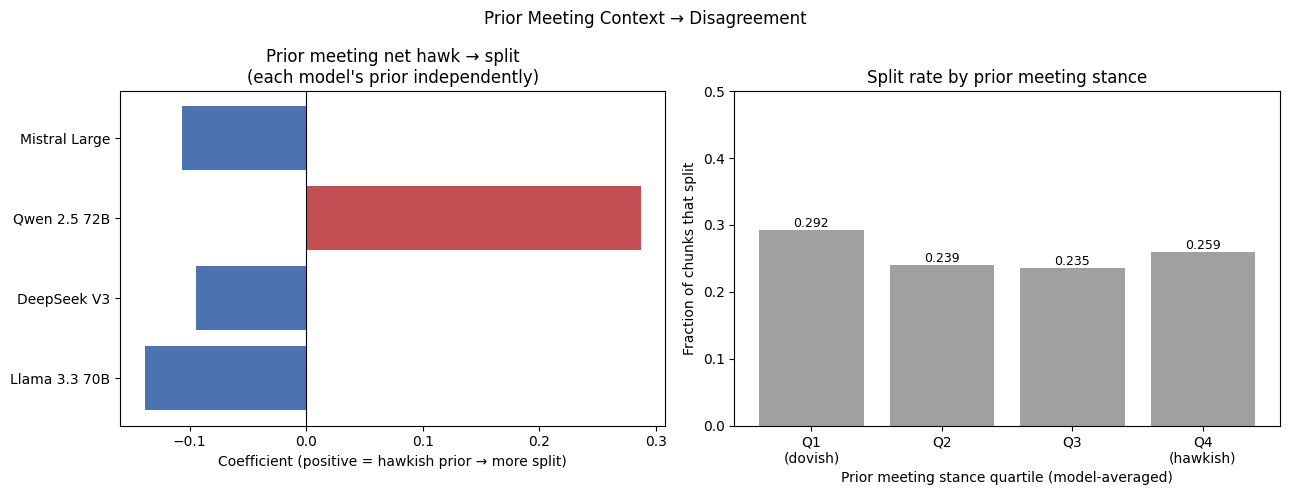

In [ ]:
# ── Prior meeting context: does previous stance predict split? ─────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Build prev_net_hawk per model per meeting
prev_frames = []
for key in loaded:
    m = all_meetings[key].sort_values(['bank', 'date']).copy()
    m[f'prev_net_hawk_{key}'] = m.groupby('bank')['net_hawk'].shift(1)
    prev_frames.append(m[['bank', 'doc_id', f'prev_net_hawk_{key}']])

prev_df = prev_frames[0]
for r in prev_frames[1:]:
    prev_df = prev_df.merge(r, on=['bank', 'doc_id'], how='left')

ctx_df = chunks_wide.merge(prev_df, on=['bank', 'doc_id'], how='left')
ctx_df['split_target'] = ctx_df['split'].astype(int)
ctx_df['word_count']   = ctx_df['text'].str.split().str.len()

prev_cols = [f'prev_net_hawk_{k}' for k in loaded]

# How many chunks have prior meeting data (first meeting per bank has no prev)
n_missing = ctx_df[prev_cols[0]].isna().sum()
print(f'Chunks missing prior meeting (first per bank): {n_missing} ({n_missing/len(ctx_df):.1%})')
ctx_df[prev_cols] = ctx_df[prev_cols].fillna(0)

# Three logit specs for comparison
specs = {
    'Prior meeting only':      prev_cols,
    'Size controls only':      ['word_count', 'n_sentences'],
    'Prior + size controls':   prev_cols + ['word_count', 'n_sentences'],
}

print(f'\n{"Spec":<30}  CV AUC')
print('-' * 45)
results = {}
for label, cols in specs.items():
    X = StandardScaler().fit_transform(ctx_df[cols].fillna(0).values)
    y = ctx_df['split_target'].values
    auc = cross_val_score(
        LogisticRegression(max_iter=1000, class_weight='balanced'),
        X, y, cv=5, scoring='roc_auc'
    ).mean()
    results[label] = auc
    print(f'{label:<30}  {auc:.3f}')

print(f'\n{"Reference — keyword baseline":<30}  0.645')
print(f'{"Reference — TF-IDF SHAP":<30}  0.676')

# Coefficient plot: which model's prior stance matters most?
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logit',  LogisticRegression(max_iter=1000, class_weight='balanced')),
])
pipe.fit(ctx_df[prev_cols].fillna(0), ctx_df['split_target'])
coef_df = pd.DataFrame({
    'model': [MODELS[k]['label'] for k in loaded],
    'coef':  pipe.named_steps['logit'].coef_[0],
})
print('\nPer-model coefficients (prior net hawk → split):')
print(coef_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: coefficient plot
ax = axes[0]
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df['coef']]
ax.barh(coef_df['model'], coef_df['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive = hawkish prior → more split)')
ax.set_title("Prior meeting net hawk → split\n(each model's prior independently)")

# Right: split rate by prior-stance quartile (model-averaged prior)
ax = axes[1]
ctx_df['mean_prev'] = ctx_df[prev_cols].mean(axis=1)
ctx_df['prev_quartile'] = pd.qcut(ctx_df['mean_prev'], q=4,
                                   labels=['Q1\n(dovish)', 'Q2', 'Q3', 'Q4\n(hawkish)'])
split_by_q = ctx_df.groupby('prev_quartile')['split_target'].mean()
ax.bar(split_by_q.index, split_by_q.values, color='#888888', alpha=0.8)
ax.set_ylabel('Fraction of chunks that split')
ax.set_xlabel('Prior meeting stance quartile (model-averaged)')
ax.set_title('Split rate by prior meeting stance')
ax.set_ylim(0, 0.5)
for i, (q, v) in enumerate(split_by_q.items()):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Prior Meeting Context → Disagreement', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'prior_meeting_context.png', dpi=150, bbox_inches='tight')
plt.show()


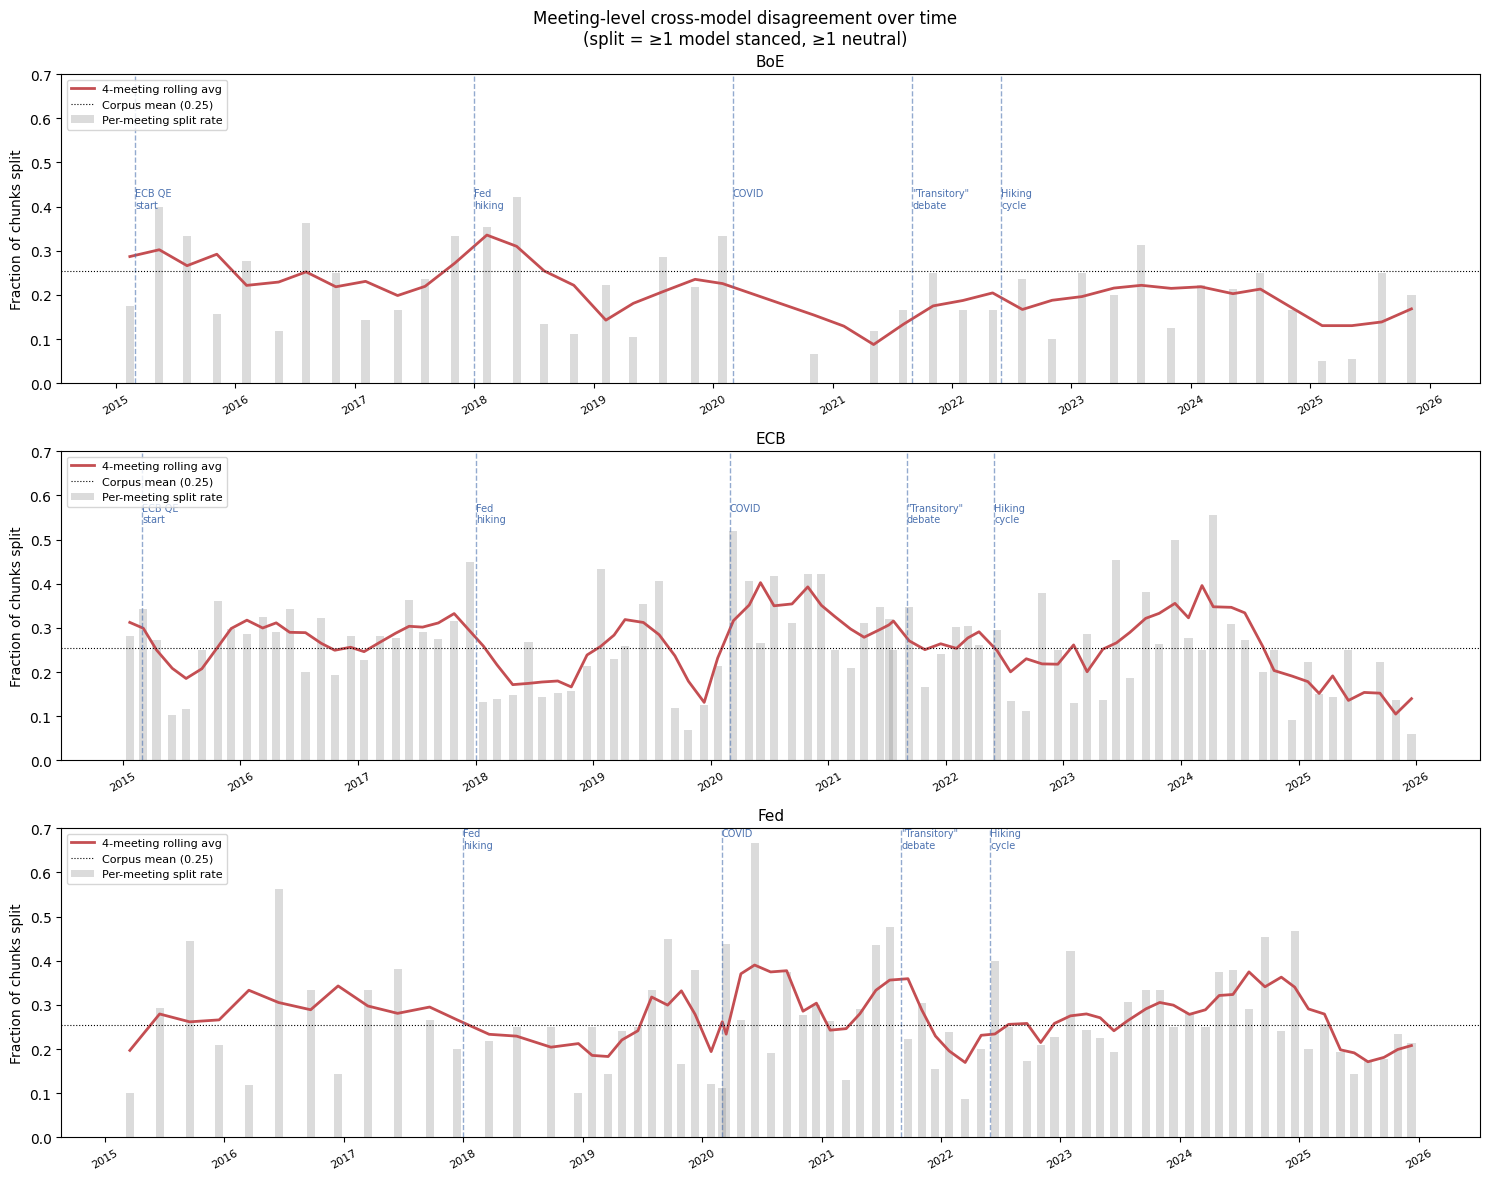

=== Meetings with highest split rate ===
bank       date  n_chunks  split_rate  mean_n_stanced
 Fed 2020-06-10        15       0.667           1.933
 Fed 2016-06-15        16       0.562           0.750
 ECB 2024-04-11         9       0.556           1.000
 ECB 2020-03-12        25       0.520           1.880
 ECB 2023-12-14        12       0.500           1.000
 Fed 2021-07-28        21       0.476           0.857
 Fed 2024-12-18        30       0.467           1.500
 ECB 2023-06-15        22       0.455           2.227
 Fed 2024-09-18        33       0.455           1.303
 ECB 2017-12-14        29       0.448           0.862

=== Mean split rate by bank ===
      count   mean    std    min    25%    50%    75%    max
bank                                                        
BoE    42.0  0.207  0.098  0.000  0.136  0.207  0.250  0.421
ECB    89.0  0.261  0.109  0.000  0.188  0.267  0.320  0.556
Fed    73.0  0.272  0.114  0.087  0.200  0.250  0.333  0.667


C:\Users\sffra\AppData\Local\Temp\ipykernel_21484\1355164149.py:63: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(3).to_string(index=False))


In [ ]:
# ── Meeting-level disagreement over time ──────────────────────────────────────
meet_disagree = chunks_wide.groupby(['bank', 'doc_id', 'date']).agg(
    n_chunks      = ('split', 'size'),
    n_split       = ('split', 'sum'),
    n_stanced_sum = ('consensus_stanced', 'sum'),
    n_neutral_sum = ('consensus_neutral', 'sum'),
    mean_n_stanced = ('n_stanced', 'mean'),
).reset_index()
meet_disagree['split_rate'] = meet_disagree['n_split'] / meet_disagree['n_chunks']
meet_disagree['date'] = pd.to_datetime(meet_disagree['date'])

# Annotate key macro episodes
EPISODES = {
    '2015-03': 'ECB QE\nstart',
    '2018-01': 'Fed\nhiking',
    '2020-03': 'COVID',
    '2021-09': '"Transitory"\ndebate',
    '2022-06': 'Hiking\ncycle',
}

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False)

for ax, bank in zip(axes, BANKS):
    bdf = meet_disagree[meet_disagree['bank'] == bank].sort_values('date')

    # Rolling 4-meeting average
    bdf = bdf.copy()
    bdf['split_rate_smooth'] = bdf['split_rate'].rolling(4, min_periods=1, center=True).mean()

    ax.bar(bdf['date'], bdf['split_rate'], width=25,
           color='#888888', alpha=0.3, label='Per-meeting split rate')
    ax.plot(bdf['date'], bdf['split_rate_smooth'], color='#C44E52',
            linewidth=2, label='4-meeting rolling avg')

    # Shade episodes
    episode_dates = {pd.to_datetime(d + '-01'): label for d, label in EPISODES.items()}
    for dt, label in episode_dates.items():
        if bdf['date'].min() <= dt <= bdf['date'].max():
            ax.axvline(dt, color='#4C72B0', linewidth=1, linestyle='--', alpha=0.6)
            ax.text(dt, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.6,
                    label, fontsize=7, color='#4C72B0', ha='left', va='top')

    ax.axhline(meet_disagree['split_rate'].mean(), color='black',
               linewidth=0.8, linestyle=':', label=f'Corpus mean ({meet_disagree["split_rate"].mean():.2f})')
    ax.set_title(bank, fontsize=11)
    ax.set_ylabel('Fraction of chunks split')
    ax.set_ylim(0, 0.7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Meeting-level cross-model disagreement over time\n(split = ≥1 model stanced, ≥1 neutral)',
             fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'timeseries_split_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("=== Meetings with highest split rate ===")
print(meet_disagree.nlargest(10, 'split_rate')[
    ['bank', 'date', 'n_chunks', 'split_rate', 'mean_n_stanced']
].round(3).to_string(index=False))

print("\n=== Mean split rate by bank ===")
print(meet_disagree.groupby('bank')['split_rate'].describe().round(3))


## 9. Save

In [ ]:
for key, meetings in all_meetings.items():
    out_path = OUT_DIR / f'meeting_scores_{key}.csv'
    meetings.to_csv(out_path, index=False)
    print(f'Saved -> {out_path}')

for key, meetings in all_meetings.items():
    print(f'\n{key}:')
    print(meetings.groupby('bank')[['net_hawk','mean_conf']].mean().round(3))

Saved -> C:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\output\stance\meeting_scores_llama33.csv
Saved -> C:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\output\stance\meeting_scores_deepseekv3.csv
Saved -> C:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\output\stance\meeting_scores_qwen25_72b.csv
Saved -> C:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\output\stance\meeting_scores_mistrallarge_or.csv

llama33:
      net_hawk  mean_conf
bank                     
BoE      0.003      2.380
ECB     -0.082      2.551
Fed     -0.028      2.445

deepseekv3:
      net_hawk  mean_conf
bank                     
BoE      0.033      1.989
ECB     -0.041      2.185
Fed      0.026      2.166

qwen25_72b:
      net_hawk  mean_conf
bank                     
BoE      0.027      1.716
ECB     -0.006      1.983
Fed      0.036      2.005

mistrallarge_or:
      net_hawk  mean_conf
bank                     
BoE      0.031      2.440
ECB     -0.047  

In [ ]:
# -- Export figures to notes/multihead_analysis/ for the analysis notesheet
import shutil

NOTES_DIR = ROOT / "notes" / "multihead_analysis"
NOTES_DIR.mkdir(parents=True, exist_ok=True)

copy_patterns = [
    "timeseries_net_hawk_*.png",
    "timeseries_disagreement_*.png",
    "timeseries_delta_*.png",
    "timeseries_split_rate.png",
    "agreement_kappa_hierarchical.png",
    "agreement_kappa_heatmap.png",
    "representation_space_llama33_deepseekv3_qwen25_72b_mistrallarge_or.png",
    "stanced_neutral_analysis.png",
]
for pattern in copy_patterns:
    for src in OUT_DIR.glob(pattern):
        shutil.copy(src, NOTES_DIR / src.name)
        print(f"  copied: {src.name}")
print(f"Done -> {NOTES_DIR}")
print("Drop Colab outputs into this directory before running pdflatex analysis_note.tex:")
print("  head_gradient_attribution.png, head_weight_similarity.png,")
print("  swap_analysis_multihead.png, confusion_matrices.png")